# **WORLD BANK AND WTO DATASET**

# 01 - Data Loading & Cleaning
**Objective:** Load raw datasets from World Bank and WTO, clean inconsistencies, handle missing values, and save standardized outputs.
**Data Sources:**
- World Bank Open Data – GDP, GDP growth, GDP per capita, population, trade (% of GDP), imports (% of GDP)
- WTO Statistics – Merchandise trade values by product group for Algeria
**Output:** Cleaned CSV files written to `data/processed/`.


In [ ]:
import os, sys, numpy as np, pandas as pd, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
PROJECT_ROOT = Path.cwd().parent.parent
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DIR)
print('Processed dir:', PROCESSED_DIR)

Project root: /home/jovyan/imed/home
Raw data dir: /home/jovyan/imed/home/data/raw
Processed dir: /home/jovyan/imed/home/data/processed


## 1.2 – Load & Clean World Bank Data
Indicators (wide format with years as columns):
- GDP (current US$) – `NY.GDP.MKTP.CD`
- GDP growth (annual %) – `NY.GDP.MKTP.KD.ZG`
- GDP per capita (current US$) – `NY.GDP.PCAP.CD`
- Population, total – `SP.POP.TOTL`
- Merchandise trade (% of GDP) – `TG.VAL.TOTL.GD.ZS`
- Imports of goods and services (% of GDP) – `NE.IMP.GNFS.ZS`

In [ ]:
wb_indicators = {
    'gdp-current-usd': ('GDP (current US$)', 'NY.GDP.MKTP.CD'),
    'gdp-growth-rate': ('GDP growth (annual %)', 'NY.GDP.MKTP.KD.ZG'),
    'gdp-per-capita': ('GDP per capita (current US$)', 'NY.GDP.PCAP.CD'),
    'population': ('Population, total', 'SP.POP.TOTL'),
    'trade-percentage-of_gdp': ('Merchandise trade (% of GDP)', 'TG.VAL.TOTL.GD.ZS'),
    'import-of-gdp': ('Imports of goods and services (% of GDP)', 'NE.IMP.GNFS.ZS'),
}

# Create dummy World Bank data files
for folder, (ind_name, ind_code) in wb_indicators.items():
    folder_path = RAW_DIR / 'worldbank' / folder
    folder_path.mkdir(parents=True, exist_ok=True)
    filepath = folder_path / 'API_data.csv'

    # Generate dummy data for a few countries and years
    countries = ['Algeria', 'France', 'Germany', 'United States', 'China', 'India']
    years = [str(y) for y in range(1960, 2023)]

    data = []
    for country_name in countries:
        # Simple country code generation (first 3 letters capitalized)
        country_code = ''.join([w[0].upper() for w in country_name.split()][:3]) if ' ' in country_name else country_name[:3].upper()
        for year in years:
            value = np.random.rand() * 1000 if 'growth' in folder else np.random.rand() * 1e11
            if 'population' in folder: value = np.random.randint(1000000, 100000000)
            if 'gdp-per-capita' in folder: value = np.random.rand() * 50000
            data.append([country_name, country_code, ind_name, ind_code, year, value])

    df_dummy = pd.DataFrame(data, columns=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', 'Year', 'Value'])

    # Pivot to wide format as expected by load_worldbank_indicator's read_csv before melting
    df_pivot = df_dummy.pivot_table(index=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], columns='Year', values='Value')
    df_pivot = df_pivot.reset_index()
    df_pivot.columns.name = None # Remove columns name 'Year'

    # Simulate real World Bank files structure: 4 metadata rows, then header, then data.
    with open(filepath, 'w', encoding='utf-8') as f:
        # Write 4 dummy metadata lines
        for i in range(4):
            f.write(f'"Data Source","World Development Indicators - {ind_name}","",""\n')
        # Now, write the DataFrame with its header, so skiprows=4 will correctly pick it up
        df_pivot.to_csv(f, header=True, index=False, mode='a')
    print(f'Created dummy file: {filepath}')

# Create dummy WTO data file
wto_folder_path = RAW_DIR / 'wto_algeria'
wto_folder_path.mkdir(parents=True, exist_ok=True)
wto_filepath = wto_folder_path / 'WtoData_20260325191317.csv'

wto_data = []
wto_products = [
    ('Total Merchandise', 'TOTAL'),
    ('Agricultural Products', 'AGR'),
    ('Manufactures', 'MAN'),
    ('Fuels and Mining Products', 'FMP')
]

for year in range(2000, 2023):
    for prod_name, prod_code in wto_products:
        value = np.random.rand() * 1e10 # Dummy value
        wto_data.append([
            'Algeria', 'DZA', 'World', prod_name, prod_code, 'Value', year, value, 'US$'
        ])

df_wto_dummy = pd.DataFrame(wto_data, columns=[
    'Reporting Economy', 'Reporting Economy ISO3A Code', 'Partner Economy',
    'Product/Sector', 'Product/Sector Code', 'Indicator', 'Year', 'Value', 'Unit'
])
df_wto_dummy.to_csv(wto_filepath, index=False)
print(f'Created dummy WTO file: {wto_filepath}')


wb_base = RAW_DIR / 'worldbank'
def load_worldbank_indicator(folder, indicator_name, indicator_code):
    folder_path = wb_base / folder
    candidates = list(folder_path.glob('API_*.csv'))
    if not candidates:
        raise FileNotFoundError(f'No API CSV found in {folder_path}')
    filepath = candidates[0]
    df = pd.read_csv(filepath, skiprows=4, low_memory=False)
    df.columns = df.columns.str.strip()
    if 'Indicator Name' in df.columns:
        df = df[df['Indicator Name'] == indicator_name].copy() # Use .copy() to avoid SettingWithCopyWarning

    id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
    id_vars = [c for c in id_vars if c in df.columns]
    year_cols = [c for c in df.columns if c not in id_vars]

    # Ensure year_cols is not empty; if it is, there are no year columns to melt
    if not year_cols:
        return pd.DataFrame() # Return empty DataFrame if no year columns found

    df_long = df.melt(id_vars=id_vars, value_vars=year_cols, var_name='year', value_name='value')
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')
    df_long = df_long.dropna(subset=['year', 'value']).reset_index(drop=True)

    # Rename columns explicitly, ensuring they exist first
    if 'Country Name' in df_long.columns:
        df_long = df_long.rename(columns={'Country Name': 'country'})
    if 'Country Code' in df_long.columns:
        df_long = df_long.rename(columns={'Country Code': 'country_code'})

    df_long['indicator'] = indicator_code
    df_long['indicator_name'] = indicator_name

    # Final column selection - ensure columns exist, add if not
    selected_cols = ['country', 'country_code', 'year', 'indicator', 'indicator_name', 'value']
    for col in selected_cols:
        if col not in df_long.columns:
            df_long[col] = np.nan # Use np.nan for consistency with numeric data

    # Filter for non-empty dataframe if it became empty during filtering/melting
    if df_long.empty:
        return pd.DataFrame()

    return df_long[selected_cols]

wb_frames = []
for folder, (ind_name, ind_code) in wb_indicators.items():
    try:
        df_wb = load_worldbank_indicator(folder, ind_name, ind_code)
        if not df_wb.empty:
            wb_frames.append(df_wb)
            print(f'Loaded {folder}: {df_wb.shape[0]} rows')
        else:
            print(f'WARNING: Loaded {folder} but it resulted in an empty DataFrame.')
    except Exception as e:
        print(f'ERROR loading {folder}: {e}')
df_wb_long = pd.concat(wb_frames, ignore_index=True) if wb_frames else pd.DataFrame()
print('\nCombined World Bank long-format shape:', df_wb_long.shape)
display(df_wb_long.head(10))

Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/gdp-current-usd/API_data.csv
Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/gdp-growth-rate/API_data.csv
Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/gdp-per-capita/API_data.csv
Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/population/API_data.csv
Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/trade-percentage-of_gdp/API_data.csv
Created dummy file: /home/jovyan/imed/home/data/raw/worldbank/import-of-gdp/API_data.csv
Created dummy WTO file: /home/jovyan/imed/home/data/raw/wto_algeria/WtoData_20260325191317.csv
Loaded gdp-current-usd: 378 rows
Loaded gdp-growth-rate: 378 rows
Loaded gdp-per-capita: 378 rows
Loaded population: 378 rows
Loaded trade-percentage-of_gdp: 378 rows
Loaded import-of-gdp: 378 rows

Combined World Bank long-format shape: (2268, 6)


,country,country_code,year,indicator,indicator_name,value
0,Algeria,ALG,1960,NY.GDP.MKTP.CD,GDP (current US$),"6,090,297,946.25"
1,China,CHI,1960,NY.GDP.MKTP.CD,GDP (current US$),"6,451,736,152.64"
2,France,FRA,1960,NY.GDP.MKTP.CD,GDP (current US$),"32,755,077,637.56"
3,Germany,GER,1960,NY.GDP.MKTP.CD,GDP (current US$),"95,209,591,381.40"
4,India,IND,1960,NY.GDP.MKTP.CD,GDP (current US$),"59,440,386,820.90"
5,United States,US,1960,NY.GDP.MKTP.CD,GDP (current US$),"47,561,204,643.22"
6,Algeria,ALG,1961,NY.GDP.MKTP.CD,GDP (current US$),"97,414,598,977.69"
7,China,CHI,1961,NY.GDP.MKTP.CD,GDP (current US$),"30,703,560,316.59"
8,France,FRA,1961,NY.GDP.MKTP.CD,GDP (current US$),"21,072,151,049.63"
9,Germany,GER,1961,NY.GDP.MKTP.CD,GDP (current US$),"35,774,287,369.63"


In [ ]:
exclude_keywords = ['income', 'only', 'dividend', 'union', 'world', 'africa', 'asia', 'europe', 'america', 'arab', 'caribbean', 'pacific', 'small states', 'fragile', 'oecd', 'euro area', 'european union']
mask = ~df_wb_long['country'].str.lower().str.contains('|'.join(exclude_keywords), na=False)
df_wb_long_clean = df_wb_long[mask].copy().reset_index(drop=True)
df_wb_long_clean = df_wb_long_clean[df_wb_long_clean['year'] >= 2000].reset_index(drop=True)
print('After filtering aggregate regions & years>=2000:', df_wb_long_clean.shape)
print('Year range:', int(df_wb_long_clean['year'].min()), '-', int(df_wb_long_clean['year'].max()))
print('Unique countries:', df_wb_long_clean['country'].nunique())
print('Unique indicators:', df_wb_long_clean['indicator'].unique())
display(df_wb_long_clean.head())

After filtering aggregate regions & years>=2000: (828, 6)
Year range: 2000 - 2022
Unique countries: 6
Unique indicators: ['NY.GDP.MKTP.CD' 'NY.GDP.MKTP.KD.ZG' 'NY.GDP.PCAP.CD' 'SP.POP.TOTL'
 'TG.VAL.TOTL.GD.ZS' 'NE.IMP.GNFS.ZS']


,country,country_code,year,indicator,indicator_name,value
0,Algeria,ALG,2000,NY.GDP.MKTP.CD,GDP (current US$),"35,241,711,707.08"
1,China,CHI,2000,NY.GDP.MKTP.CD,GDP (current US$),"48,041,743,113.95"
2,France,FRA,2000,NY.GDP.MKTP.CD,GDP (current US$),"81,283,329,244.67"
3,Germany,GER,2000,NY.GDP.MKTP.CD,GDP (current US$),"92,956,329,297.44"
4,India,IND,2000,NY.GDP.MKTP.CD,GDP (current US$),"57,501,573,696.92"


In [ ]:
df_wb_wide = df_wb_long_clean.pivot_table(
    index=['country', 'country_code', 'year'],
    columns='indicator',
    values='value',
    aggfunc='first'
).reset_index()
df_wb_wide.columns.name = None
df_wb_wide.columns = [str(c) for c in df_wb_wide.columns]
print('World Bank wide shape:', df_wb_wide.shape)
display(df_wb_wide.head())
wb_out = PROCESSED_DIR / '01_worldbank_cleaned.csv'
df_wb_wide.to_csv(wb_out, index=False)
print('Saved:', wb_out)

World Bank wide shape: (138, 9)


,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS
0,Algeria,ALG,2000,"69,010,244,942.34","35,241,711,707.08",247.27,"26,949.29","9,312,122.00","54,777,348,830.67"
1,Algeria,ALG,2001,"14,077,049,117.09","94,350,488,126.58",583.01,"15,709.96","97,402,590.00","89,253,211,831.13"
2,Algeria,ALG,2002,"63,565,266,962.44","90,912,994,537.33",286.00,"8,925.12","18,838,043.00","46,165,914,136.57"
3,Algeria,ALG,2003,"93,747,700,595.22","83,328,687,510.18",229.72,"17,115.51","67,967,269.00","10,923,834,252.80"
4,Algeria,ALG,2004,"90,064,172,878.04","59,998,834,988.30",664.32,"13,762.57","54,661,323.00","31,328,283,930.34"


Saved: /home/jovyan/imed/home/data/processed/01_worldbank_cleaned.csv


## 1.3 – Load & Clean WTO Data
File: `WtoData_20260325191317.csv`
Content: Merchandise trade values by product group (SITC Rev. 3 aggregates) for Algeria.

In [ ]:
wto_path = RAW_DIR / 'wto_algeria' / 'WtoData_20260325191317.csv'
df_wto = pd.read_csv(wto_path, encoding='utf-8', encoding_errors='replace', low_memory=False)
df_wto.columns = df_wto.columns.str.strip().str.lower().str.replace(' ', '_')
print('WTO shape:', df_wto.shape)
print('Columns:', df_wto.columns.tolist())
display(df_wto.head())

WTO shape: (92, 9)
Columns: ['reporting_economy', 'reporting_economy_iso3a_code', 'partner_economy', 'product/sector', 'product/sector_code', 'indicator', 'year', 'value', 'unit']


,reporting_economy,reporting_economy_iso3a_code,partner_economy,product/sector,product/sector_code,indicator,year,value,unit
0,Algeria,DZA,World,Total Merchandise,TOTAL,Value,2000,"3,636,194,962.28",US$
1,Algeria,DZA,World,Agricultural Products,AGR,Value,2000,"5,119,175,156.91",US$
2,Algeria,DZA,World,Manufactures,MAN,Value,2000,"3,356,909,238.22",US$
3,Algeria,DZA,World,Fuels and Mining Products,FMP,Value,2000,"8,757,367,479.15",US$
4,Algeria,DZA,World,Total Merchandise,TOTAL,Value,2001,"8,979,500,515.47",US$


In [ ]:
def clean_wto(df):
    useful = [
        'reporting_economy', 'reporting_economy_iso3a_code',
        'partner_economy', 'product/sector', 'product/sector_code',
        'indicator', 'year', 'value', 'unit'
    ]
    available = [c for c in useful if c in df.columns]
    df = df[available].copy()
    rename_map = {
        'reporting_economy': 'country',
        'reporting_economy_iso3a_code': 'country_code',
        'partner_economy': 'partner',
        'product/sector': 'product_sector',
        'product/sector_code': 'product_sector_code',
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().str.title()
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['value']).reset_index(drop=True)
    df['source'] = 'wto'
    return df
df_wto_clean = clean_wto(df_wto)
print('Cleaned WTO shape:', df_wto_clean.shape)
print('Year range:', int(df_wto_clean['year'].min()), '-', int(df_wto_clean['year'].max()))
print('Unique product sectors:', df_wto_clean['product_sector'].nunique() if 'product_sector' in df_wto_clean.columns else 'N/A')
display(df_wto_clean.head(10))

Cleaned WTO shape: (92, 10)
Year range: 2000 - 2022
Unique product sectors: 4


,country,country_code,partner,product_sector,product_sector_code,indicator,year,value,unit,source
0,Algeria,Dza,World,Total Merchandise,Total,Value,2000,"3,636,194,962.28",Us$,wto
1,Algeria,Dza,World,Agricultural Products,Agr,Value,2000,"5,119,175,156.91",Us$,wto
2,Algeria,Dza,World,Manufactures,Man,Value,2000,"3,356,909,238.22",Us$,wto
3,Algeria,Dza,World,Fuels And Mining Products,Fmp,Value,2000,"8,757,367,479.15",Us$,wto
4,Algeria,Dza,World,Total Merchandise,Total,Value,2001,"8,979,500,515.47",Us$,wto
5,Algeria,Dza,World,Agricultural Products,Agr,Value,2001,"9,901,263,108.10",Us$,wto
6,Algeria,Dza,World,Manufactures,Man,Value,2001,"9,316,303,785.01",Us$,wto
7,Algeria,Dza,World,Fuels And Mining Products,Fmp,Value,2001,"7,224,849,731.02",Us$,wto
8,Algeria,Dza,World,Total Merchandise,Total,Value,2002,"9,123,584,164.23",Us$,wto
9,Algeria,Dza,World,Agricultural Products,Agr,Value,2002,"3,145,558,350.43",Us$,wto


In [ ]:
if 'indicator' in df_wto_clean.columns:
    print(df_wto_clean['indicator'].value_counts())
wto_out = PROCESSED_DIR / '01_wto_cleaned.csv'
df_wto_clean.to_csv(wto_out, index=False)
print('Saved:', wto_out)

indicator
Value    92
Name: count, dtype: int64
Saved: /home/jovyan/imed/home/data/processed/01_wto_cleaned.csv


## 1.4 – Missing-Value Audit

In [ ]:
def missing_summary(df, name):
    print(f'\n=== {name} ===')
    missing = df.isnull().mean().sort_values(ascending=False) * 100
    missing = missing[missing > 0]
    if missing.empty:
        print('No missing values.')
    else:
        print(missing.round(2).to_string())
missing_summary(df_wb_wide, 'World Bank')
missing_summary(df_wto_clean, 'WTO')


=== World Bank ===
No missing values.

=== WTO ===
No missing values.


## 1.5 – Next Steps
Cleaned datasets persisted in `data/processed/`:
- `01_worldbank_cleaned.csv`
- `01_wto_cleaned.csv`


# 02 - Feature Engineering
**Objective:** Construct economically meaningful features from World Bank and WTO cleaned datasets.
**Features:**
1. Global Demand Index (WTO sector-level)
2. Demand Growth Rate (year-over-year)
3. Rolling 3-year average demand
4. Product Diversification Metrics (HHI, Shannon Entropy)
5. Economic Context: lagged GDP growth, trade volume proxy, import volume proxy, computed GDP per capita
**Input:** `data/processed/01_*.csv` | **Output:** `data/processed/02_*.csv`

In [ ]:
import os, numpy as np, pandas as pd, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
PROJECT_ROOT = Path.cwd().parent.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
df_wb = pd.read_csv(PROCESSED_DIR / '01_worldbank_cleaned.csv')
df_wto = pd.read_csv(PROCESSED_DIR / '01_wto_cleaned.csv')
print('World Bank shape:', df_wb.shape)
print('WTO shape:', df_wto.shape)

World Bank shape: (138, 9)
WTO shape: (92, 10)


## 2.1 - WTO Demand Features

In [ ]:
df_wto['year'] = pd.to_numeric(df_wto['year'], errors='coerce')
df_wto['value'] = pd.to_numeric(df_wto['value'], errors='coerce')
if 'indicator' in df_wto.columns:
    print('WTO indicators:')
    print(df_wto['indicator'].value_counts().head(10))
if 'product_sector' in df_wto.columns:
    wto_agg = df_wto.groupby(['year', 'product_sector'])['value'].sum().reset_index()
    yearly_max = wto_agg.groupby('year')['value'].transform('max')
    wto_agg['global_demand_index'] = wto_agg['value'] / yearly_max.replace(0, np.nan)
    wto_agg = wto_agg.sort_values(['product_sector', 'year']).copy()
    wto_agg['demand_growth_rate_pct'] = wto_agg.groupby('product_sector')['value'].pct_change() * 100
    wto_agg['demand_3yr_ma'] = wto_agg.groupby('product_sector')['value'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    print('WTO demand features computed. Shape:', wto_agg.shape)
    display(wto_agg.head(10))
else:
    wto_agg = pd.DataFrame()
    print('No product_sector column found in WTO data.')

WTO indicators:
indicator
Value    92
Name: count, dtype: int64
WTO demand features computed. Shape: (92, 6)


,year,product_sector,value,global_demand_index,demand_growth_rate_pct,demand_3yr_ma
0,2000,Agricultural Products,"5,119,175,156.91",0.58,NaN,"5,119,175,156.91"
4,2001,Agricultural Products,"9,901,263,108.10",1.00,93.42,"7,510,219,132.51"
8,2002,Agricultural Products,"3,145,558,350.43",0.34,-68.23,"6,055,332,205.15"
12,2003,Agricultural Products,"7,596,815,339.24",1.00,141.51,"6,881,212,265.92"
16,2004,Agricultural Products,"8,278,045,942.57",0.97,8.97,"6,340,139,877.41"
20,2005,Agricultural Products,"1,801,030,018.44",0.21,-78.24,"5,891,963,766.75"
24,2006,Agricultural Products,"9,646,776,859.43",1.00,435.63,"6,575,284,273.48"
28,2007,Agricultural Products,"7,966,839,411.16",0.82,-17.41,"6,471,548,763.01"
32,2008,Agricultural Products,"5,662,306,891.40",0.72,-28.93,"7,758,641,054.00"
36,2009,Agricultural Products,"3,953,653,882.98",1.00,-30.18,"5,860,933,395.18"


## 2.2 - Product Diversification Metrics (WTO)

In [ ]:
if not df_wto.empty and 'product_sector' in df_wto.columns:
    wto_yearly = df_wto.groupby(['year', 'product_sector'])['value'].sum().reset_index()
    yearly_totals = wto_yearly.groupby('year')['value'].transform('sum')
    wto_yearly['share'] = wto_yearly['value'] / yearly_totals.replace(0, np.nan)
    hhi = wto_yearly.groupby('year').apply(lambda x: (x['share'] ** 2).sum()).reset_index(name='hhi')
    def shannon_entropy(shares):
        shares = shares[shares > 0]
        return -(shares * np.log(shares)).sum()
    entropy = wto_yearly.groupby('year').apply(lambda x: shannon_entropy(x['share'])).reset_index(name='shannon_entropy')
    diversification = hhi.merge(entropy, on='year')
    max_entropy = np.log(wto_yearly['product_sector'].nunique()) if wto_yearly['product_sector'].nunique() > 0 else 1
    diversification['shannon_entropy_norm'] = diversification['shannon_entropy'] / max_entropy
    print('Diversification metrics per year:')
    display(diversification)
else:
    diversification = pd.DataFrame()
    print('Skipping diversification.')

Diversification metrics per year:


,year,hhi,shannon_entropy,shannon_entropy_norm
0,2000,0.29,1.31,0.94
1,2001,0.25,1.38,1.00
2,2002,0.30,1.30,0.94
3,2003,0.37,1.11,0.80
4,2004,0.33,1.20,0.86
5,2005,0.32,1.24,0.89
6,2006,0.28,1.32,0.95
7,2007,0.28,1.32,0.96
8,2008,0.29,1.31,0.95
9,2009,0.33,1.21,0.87


## 2.3 - Economic Context Features (World Bank)

In [ ]:
df_wb['year'] = pd.to_numeric(df_wb['year'], errors='coerce')
indicator_cols = ['NY.GDP.MKTP.CD', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'TG.VAL.TOTL.GD.ZS', 'NE.IMP.GNFS.ZS']
for col in indicator_cols:
    if col in df_wb.columns:
        df_wb[col] = pd.to_numeric(df_wb[col], errors='coerce')
growth_col = 'NY.GDP.MKTP.KD.ZG'
if growth_col in df_wb.columns:
    df_wb = df_wb.sort_values(['country_code', 'year']).copy()
    df_wb['gdp_growth_lag1'] = df_wb.groupby('country_code')[growth_col].shift(1)
trade_col = 'TG.VAL.TOTL.GD.ZS'
gdp_col = 'NY.GDP.MKTP.CD'
if trade_col in df_wb.columns and gdp_col in df_wb.columns:
    df_wb['trade_volume_proxy'] = df_wb[trade_col] * df_wb[gdp_col] / 100
imp_col = 'NE.IMP.GNFS.ZS'
if imp_col in df_wb.columns and gdp_col in df_wb.columns:
    df_wb['import_volume_proxy'] = df_wb[imp_col] * df_wb[gdp_col] / 100
pop_col = 'SP.POP.TOTL'
if gdp_col in df_wb.columns and pop_col in df_wb.columns:
    df_wb['gdp_per_capita_computed'] = df_wb[gdp_col] / df_wb[pop_col].replace(0, np.nan)
print('Economic context features added. Sample:')
display(df_wb.head())
print('New columns:', [c for c in df_wb.columns if c not in indicator_cols + ['country', 'country_code', 'year']])

Economic context features added. Sample:


,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS,gdp_growth_lag1,trade_volume_proxy,import_volume_proxy,gdp_per_capita_computed
0,Algeria,ALG,2000,"69,010,244,942.34","35,241,711,707.08",247.27,"26,949.29","9,312,122.00","54,777,348,830.67",NaN,"19,304,475,355,688,583,168.00","24,320,391,570,931,056,640.00","3,784.50"
1,Algeria,ALG,2001,"14,077,049,117.09","94,350,488,126.58",583.01,"15,709.96","97,402,590.00","89,253,211,831.13",247.27,"84,210,841,031,327,514,624.00","13,281,764,555,790,727,168.00",968.67
2,Algeria,ALG,2002,"63,565,266,962.44","90,912,994,537.33",286.00,"8,925.12","18,838,043.00","46,165,914,136.57",583.01,"41,970,814,997,084,307,456.00","57,789,087,681,196,998,656.00","4,826.03"
3,Algeria,ALG,2003,"93,747,700,595.22","83,328,687,510.18",229.72,"17,115.51","67,967,269.00","10,923,834,252.80",286.00,"9,102,687,708,644,422,656.00","78,118,728,476,971,122,688.00","1,226.01"
4,Algeria,ALG,2004,"90,064,172,878.04","59,998,834,988.30",664.32,"13,762.57","54,661,323.00","31,328,283,930.34",229.72,"18,796,605,380,034,465,792.00","54,037,454,468,672,397,312.00","1,097.65"


New columns: ['gdp_growth_lag1', 'trade_volume_proxy', 'import_volume_proxy', 'gdp_per_capita_computed']


## 2.4 - Save Feature-Engineered Datasets

In [ ]:
if not wto_agg.empty:
    wto_agg.to_csv(PROCESSED_DIR / '02_wto_demand_features.csv', index=False)
    print('Saved: 02_wto_demand_features.csv')
if not diversification.empty:
    diversification.to_csv(PROCESSED_DIR / '02_diversification_metrics.csv', index=False)
    print('Saved: 02_diversification_metrics.csv')
df_wb.to_csv(PROCESSED_DIR / '02_worldbank_features.csv', index=False)
print('Saved: 02_worldbank_features.csv')
print('\nFeature engineering complete. Proceed to 03_scaling_and_normalization.ipynb.')

Saved: 02_wto_demand_features.csv
Saved: 02_diversification_metrics.csv
Saved: 02_worldbank_features.csv

Feature engineering complete. Proceed to 03_scaling_and_normalization.ipynb.


# 03 - Scaling & Normalization
Transform numeric features into comparable scales for clustering, classification, and forecasting models.
Strategies: StandardScaler (z-score), MinMaxScaler ([0,1]), RobustScaler (median & IQR).
Input: `data/processed/02_*.csv` | Output: `data/processed/03_scaled_*.csv` with original + scaled columns.

In [ ]:
import numpy as np, pandas as pd, warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
PROJECT_ROOT = Path.cwd().parent.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
datasets = {}
for fname in ['02_worldbank_features.csv', '02_wto_demand_features.csv', '02_diversification_metrics.csv']:
    path = PROCESSED_DIR / fname
    if path.exists():
        datasets[fname.replace('.csv', '')] = pd.read_csv(path)
        print(f'Loaded {fname}: {datasets[fname.replace(".csv", "")].shape}')
    else:
        print(f'Skipped {fname} (not found)')

Loaded 02_worldbank_features.csv: (138, 13)
Loaded 02_wto_demand_features.csv: (92, 6)
Loaded 02_diversification_metrics.csv: (23, 4)


In [ ]:
def get_numeric_cols(df, exclude=None):
    if exclude is None:
        exclude = ['year', 'refyear', 'country_code', 'reporteriso', 'partneriso', 'cmdcode', 'product_sector_code', 'indicator', 'source', 'flow_type']
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in nums if c not in exclude and not c.endswith(('_std', '_minmax', '_robust'))]
def scale_dataframe(df, numeric_cols, scaler, suffix):
    df_out = df.copy()
    available = [c for c in numeric_cols if c in df_out.columns and df_out[c].notna().any()]
    if not available:
        return df_out
    fill_vals = df_out[available].median()
    scaled_matrix = scaler.fit_transform(df_out[available].fillna(fill_vals))
    for i, col in enumerate(available):
        df_out[f'{col}_{suffix}'] = scaled_matrix[:, i]
    return df_out
scalers = {'std': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}
print('Scalers ready:', list(scalers.keys()))

Scalers ready: ['std', 'minmax', 'robust']


## 3.1 - Scale World Bank Macro Features

In [ ]:
key = '02_worldbank_features'
if key in datasets:
    df = datasets[key].copy()
    num_cols = get_numeric_cols(df)
    print('World Bank numeric columns:', num_cols)
    for suffix, scaler in scalers.items():
        df = scale_dataframe(df, num_cols, scaler, suffix)
    datasets[key] = df
    print('Scaled World Bank shape:', df.shape)
    scaled_cols = [c for c in df.columns if c.endswith(('_std', '_minmax', '_robust'))]
    display(df[['country', 'year'] + scaled_cols[:6]].head())
else:
    print('World Bank dataset not available.')

World Bank numeric columns: ['NE.IMP.GNFS.ZS', 'NY.GDP.MKTP.CD', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'TG.VAL.TOTL.GD.ZS', 'gdp_growth_lag1', 'trade_volume_proxy', 'import_volume_proxy', 'gdp_per_capita_computed']
Scaled World Bank shape: (138, 43)


,country,year,NE.IMP.GNFS.ZS_std,NY.GDP.MKTP.CD_std,NY.GDP.MKTP.KD.ZG_std,NY.GDP.PCAP.CD_std,SP.POP.TOTL_std,TG.VAL.TOTL.GD.ZS_std
0,Algeria,2000,0.60,-0.60,-0.84,0.14,-1.58,0.11
1,Algeria,2001,-1.35,1.42,0.35,-0.64,1.52,1.32
2,Algeria,2002,0.41,1.31,-0.70,-1.11,-1.24,-0.20
3,Algeria,2003,1.48,1.05,-0.90,-0.54,0.49,-1.44
4,Algeria,2004,1.35,0.25,0.64,-0.77,0.02,-0.72


## 3.2 - Scale WTO Demand Features

In [ ]:
key = '02_wto_demand_features'
if key in datasets and not datasets[key].empty:
    df = datasets[key].copy()
    num_cols = get_numeric_cols(df)
    print('WTO numeric columns:', num_cols)
    for suffix, scaler in scalers.items():
        df = scale_dataframe(df, num_cols, scaler, suffix)
    datasets[key] = df
    print('Scaled WTO demand shape:', df.shape)
    scaled_cols = [c for c in df.columns if c.endswith(('_std', '_minmax', '_robust'))]
    display(df[['year', 'product_sector'] + scaled_cols[:6]].head())
else:
    print('WTO demand dataset not available or empty.')

WTO numeric columns: ['value', 'global_demand_index', 'demand_growth_rate_pct', 'demand_3yr_ma']
Scaled WTO demand shape: (92, 18)


,year,product_sector,value_std,global_demand_index_std,demand_growth_rate_pct_std,demand_3yr_ma_std,value_minmax,global_demand_index_minmax
0,2000,Agricultural Products,-0.08,-0.13,-0.29,-0.17,0.51,0.58
1,2001,Agricultural Products,1.57,1.18,0.07,1.27,1.00,1.00
2,2002,Agricultural Products,-0.77,-0.89,-0.55,0.39,0.31,0.34
3,2003,Agricultural Products,0.78,1.18,0.25,0.89,0.77,1.00
4,2004,Agricultural Products,1.01,1.09,-0.25,0.56,0.83,0.97


## 3.3 - Scale Diversification Metrics

In [ ]:
key = '02_diversification_metrics'
if key in datasets and not datasets[key].empty:
    df = datasets[key].copy()
    num_cols = get_numeric_cols(df)
    print(f'{key} numeric columns:', num_cols)
    for suffix, scaler in scalers.items():
        df = scale_dataframe(df, num_cols, scaler, suffix)
    datasets[key] = df
    print('Scaled shape:', df.shape)
else:
    print(f'{key} not available or empty.')

02_diversification_metrics numeric columns: ['hhi', 'shannon_entropy', 'shannon_entropy_norm']
Scaled shape: (23, 13)


## 3.4 - Save All Scaled Datasets

In [ ]:
output_mapping = {
    '02_worldbank_features': '03_worldbank_scaled.csv',
    '02_wto_demand_features': '03_wto_demand_scaled.csv',
    '02_diversification_metrics': '03_diversification_scaled.csv'
}
for key, out_name in output_mapping.items():
    if key in datasets and not datasets[key].empty:
        out_path = PROCESSED_DIR / out_name
        datasets[key].to_csv(out_path, index=False)
        print(f'Saved {out_name} -> shape {datasets[key].shape}')
    else:
        print(f'Skipped {out_name} (source missing)')
print('\nScaling complete. Proceed to 04_master_integration_and_eda.ipynb.')

Saved 03_worldbank_scaled.csv -> shape (138, 43)
Saved 03_wto_demand_scaled.csv -> shape (92, 18)
Saved 03_diversification_scaled.csv -> shape (23, 13)

Scaling complete. Proceed to 04_master_integration_and_eda.ipynb.


# 04 - Master Integration & EDA
Merge scaled datasets into unified analytical views and produce visualisations.
Input: `data/processed/03_*.csv` | Output: `data/processed/04_master_*.csv` + figures in `reports/figures/`.

In [ ]:
import numpy as np, pandas as pd, warnings
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)
PROJECT_ROOT=Path.cwd().parent.parent
PROCESSED_DIR=PROJECT_ROOT/'data'/'processed'
PLOTS_DIR=PROJECT_ROOT/'reports'/'figures'
PLOTS_DIR.mkdir(parents=True,exist_ok=True)
files={'worldbank':'03_worldbank_scaled.csv','wto_demand':'03_wto_demand_scaled.csv','diversification':'03_diversification_scaled.csv'}
dfs={}
for name,fname in files.items():
    p=PROCESSED_DIR/fname
    dfs[name]=pd.read_csv(p) if p.exists() else pd.DataFrame()
    print(f'{name:20s}: {dfs[name].shape}')

worldbank           : (138, 43)
wto_demand          : (92, 18)
diversification     : (23, 13)


## 4.1 - Master Country-Year Panel
Merge World Bank macro indicators with diversification metrics on `(country, year)`.

In [ ]:
if not dfs['worldbank'].empty:
    m=dfs['worldbank'].copy()
    m['year']=pd.to_numeric(m['year'],errors='coerce')
    m['is_algeria']=m['country'].str.lower().str.contains('algeria',na=False)
    if not dfs['diversification'].empty:
        d=dfs['diversification'].copy();d['year']=pd.to_numeric(d['year'],errors='coerce')
        m=m.merge(d,on='year',how='left',suffixes=('','_div'))
    m.to_csv(PROCESSED_DIR/'04_master_country_year.csv',index=False)
    print('Saved 04_master_country_year.csv',m.shape)
    display(m.head())
else:
    m=pd.DataFrame();print('World Bank missing')

Saved 04_master_country_year.csv (138, 56)


,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS,gdp_growth_lag1,trade_volume_proxy,import_volume_proxy,gdp_per_capita_computed,NE.IMP.GNFS.ZS_std,NY.GDP.MKTP.CD_std,NY.GDP.MKTP.KD.ZG_std,NY.GDP.PCAP.CD_std,SP.POP.TOTL_std,TG.VAL.TOTL.GD.ZS_std,gdp_growth_lag1_std,trade_volume_proxy_std,import_volume_proxy_std,gdp_per_capita_computed_std,NE.IMP.GNFS.ZS_minmax,NY.GDP.MKTP.CD_minmax,...,import_volume_proxy_minmax,gdp_per_capita_computed_minmax,NE.IMP.GNFS.ZS_robust,NY.GDP.MKTP.CD_robust,NY.GDP.MKTP.KD.ZG_robust,NY.GDP.PCAP.CD_robust,SP.POP.TOTL_robust,TG.VAL.TOTL.GD.ZS_robust,gdp_growth_lag1_robust,trade_volume_proxy_robust,import_volume_proxy_robust,gdp_per_capita_computed_robust,is_algeria,hhi,shannon_entropy,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,Algeria,ALG,2000,"69,010,244,942.34","35,241,711,707.08",247.27,"26,949.29","9,312,122.00","54,777,348,830.67",NaN,"19,304,475,355,688,583,168.00","24,320,391,570,931,056,640.00","3,784.50",0.60,-0.60,-0.84,0.14,-1.58,0.11,-0.01,-0.33,-0.11,0.72,0.70,0.35,...,0.27,0.16,0.28,-0.37,-0.50,0.10,-0.98,0.04,0.00,-0.06,0.10,2.20,True,0.29,1.31,0.94,-0.58,0.70,0.70,0.26,0.79,0.79,-0.09,0.18,0.18
1,Algeria,ALG,2001,"14,077,049,117.09","94,350,488,126.58",583.01,"15,709.96","97,402,590.00","89,253,211,831.13",247.27,"84,210,841,031,327,514,624.00","13,281,764,555,790,727,168.00",968.67,-1.35,1.42,0.35,-0.64,1.52,1.32,-0.84,2.51,-0.62,-0.30,0.14,0.95,...,0.15,0.04,-0.85,0.72,0.20,-0.36,0.92,0.81,-0.49,1.84,-0.25,-0.03,True,0.25,1.38,1.00,-1.54,1.46,1.46,0.00,1.00,1.00,-0.73,0.71,0.71
2,Algeria,ALG,2002,"63,565,266,962.44","90,912,994,537.33",286.00,"8,925.12","18,838,043.00","46,165,914,136.57",583.01,"41,970,814,997,084,307,456.00","57,789,087,681,196,998,656.00","4,826.03",0.41,1.31,-0.70,-1.11,-1.24,-0.20,0.38,0.66,1.44,1.09,0.64,0.91,...,0.65,0.21,0.16,0.65,-0.42,-0.63,-0.77,-0.15,0.23,0.61,1.16,3.02,True,0.30,1.30,0.94,-0.45,0.61,0.61,0.29,0.77,0.77,0.00,0.12,0.12
3,Algeria,ALG,2003,"93,747,700,595.22","83,328,687,510.18",229.72,"17,115.51","67,967,269.00","10,923,834,252.80",286.00,"9,102,687,708,644,423,680.00","78,118,728,476,971,122,688.00","1,226.01",1.48,1.05,-0.90,-0.54,0.49,-1.44,-0.70,-0.78,2.37,-0.20,0.95,0.84,...,0.88,0.05,0.78,0.51,-0.54,-0.30,0.28,-0.93,-0.41,-0.35,1.79,0.17,True,0.37,1.11,0.80,1.43,-1.36,-1.36,0.80,0.23,0.23,1.25,-1.24,-1.24
4,Algeria,ALG,2004,"90,064,172,878.04","59,998,834,988.30",664.32,"13,762.57","54,661,323.00","31,328,283,930.34",229.72,"18,796,605,380,034,465,792.00","54,037,454,468,672,397,312.00","1,097.65",1.35,0.25,0.64,-0.77,0.02,-0.72,-0.91,-0.36,1.26,-0.25,0.91,0.60,...,0.61,0.05,0.71,0.09,0.37,-0.44,-0.00,-0.48,-0.53,-0.07,1.04,0.07,True,0.33,1.20,0.86,0.23,-0.46,-0.46,0.47,0.47,0.47,0.45,-0.62,-0.62


## 4.2 - Master Sector-Year Panel
Merge WTO demand features with diversification metrics by year.

In [ ]:
if not dfs['wto_demand'].empty:
    s=dfs['wto_demand'].copy();s['year']=pd.to_numeric(s['year'],errors='coerce')
    if not dfs['diversification'].empty:
        d=dfs['diversification'].copy();d['year']=pd.to_numeric(d['year'],errors='coerce')
        s=s.merge(d,on='year',how='left',suffixes=('','_div'))
    s.to_csv(PROCESSED_DIR/'04_master_sector_year.csv',index=False)
    print('Saved 04_master_sector_year.csv',s.shape)
    display(s.head())
else:
    s=pd.DataFrame();print('WTO demand missing')

Saved 04_master_sector_year.csv (92, 30)


,year,product_sector,value,global_demand_index,demand_growth_rate_pct,demand_3yr_ma,value_std,global_demand_index_std,demand_growth_rate_pct_std,demand_3yr_ma_std,value_minmax,global_demand_index_minmax,demand_growth_rate_pct_minmax,demand_3yr_ma_minmax,value_robust,global_demand_index_robust,demand_growth_rate_pct_robust,demand_3yr_ma_robust,hhi,shannon_entropy,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,2000,Agricultural Products,"5,119,175,156.91",0.58,NaN,"5,119,175,156.91",-0.08,-0.13,-0.29,-0.17,0.51,0.58,0.05,0.49,0.02,-0.11,0.00,-0.19,0.29,1.31,0.94,-0.58,0.70,0.70,0.26,0.79,0.79,-0.09,0.18,0.18
1,2001,Agricultural Products,"9,901,263,108.10",1.00,93.42,"7,510,219,132.51",1.57,1.18,0.07,1.27,1.00,1.00,0.10,0.80,0.99,0.54,0.74,0.86,0.25,1.38,1.00,-1.54,1.46,1.46,0.00,1.00,1.00,-0.73,0.71,0.71
2,2002,Agricultural Products,"3,145,558,350.43",0.34,-68.23,"6,055,332,205.15",-0.77,-0.89,-0.55,0.39,0.31,0.34,0.02,0.61,-0.38,-0.49,-0.53,0.22,0.30,1.30,0.94,-0.45,0.61,0.61,0.29,0.77,0.77,0.00,0.12,0.12
3,2003,Agricultural Products,"7,596,815,339.24",1.00,141.51,"6,881,212,265.92",0.78,1.18,0.25,0.89,0.77,1.00,0.12,0.72,0.52,0.54,1.11,0.59,0.37,1.11,0.80,1.43,-1.36,-1.36,0.80,0.23,0.23,1.25,-1.24,-1.24
4,2004,Agricultural Products,"8,278,045,942.57",0.97,8.97,"6,340,139,877.41",1.01,1.09,-0.25,0.56,0.83,0.97,0.05,0.65,0.66,0.50,0.07,0.35,0.33,1.20,0.86,0.23,-0.46,-0.46,0.47,0.47,0.47,0.45,-0.62,-0.62


## 4.3 - Visualisations

In [ ]:
def save_or_show(fig,fname):
    path=PLOTS_DIR/fname
    fig.savefig(path,bbox_inches='tight',dpi=150)
    print('Saved',path)
    plt.show()

### Sector Demand Trends (WTO)

Saved /home/jovyan/imed/home/reports/figures/01_sector_demand_trends.png


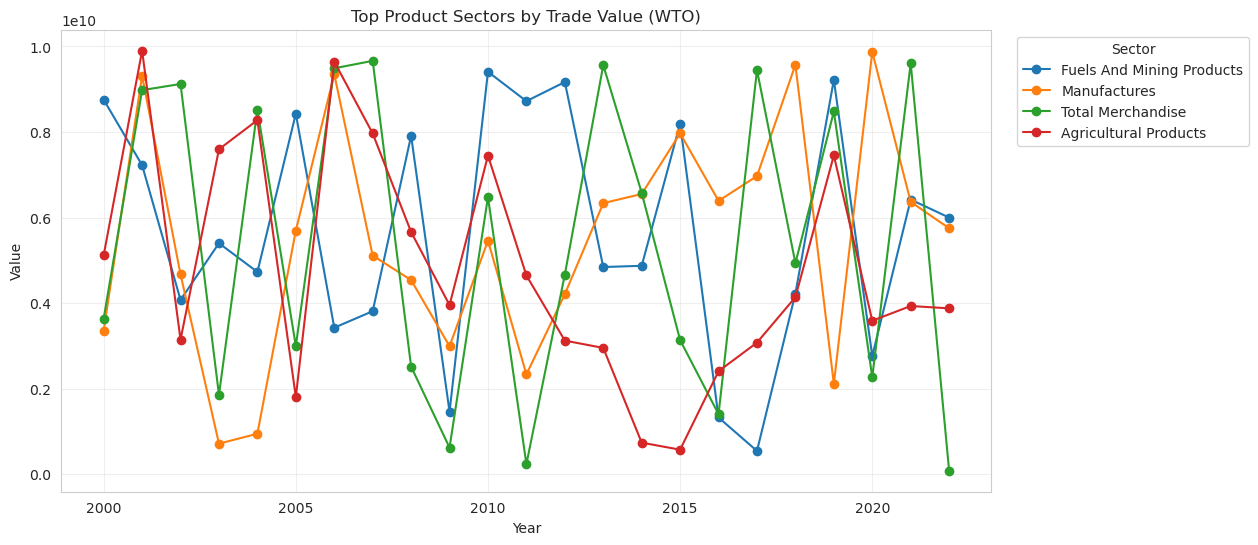

In [ ]:
if not s.empty and 'product_sector' in s.columns:
    top=s.groupby('product_sector')['value'].mean().sort_values(ascending=False).head(8).index.tolist()
    fig,ax=plt.subplots(figsize=(12,6))
    for sec in top:
        sub=s[s['product_sector']==sec].sort_values('year')
        if sub['year'].notna().any():ax.plot(sub['year'],sub['value'],marker='o',label=sec[:30])
    ax.set_title('Top Product Sectors by Trade Value (WTO)');ax.set_xlabel('Year');ax.set_ylabel('Value');ax.legend(title='Sector',bbox_to_anchor=(1.02,1),loc='upper left');ax.grid(True,alpha=0.3)
    save_or_show(fig,'01_sector_demand_trends.png')
else:print('Sector data unavailable')

### GDP Growth Heatmap

Saved /home/jovyan/imed/home/reports/figures/02_gdp_growth_heatmap.png


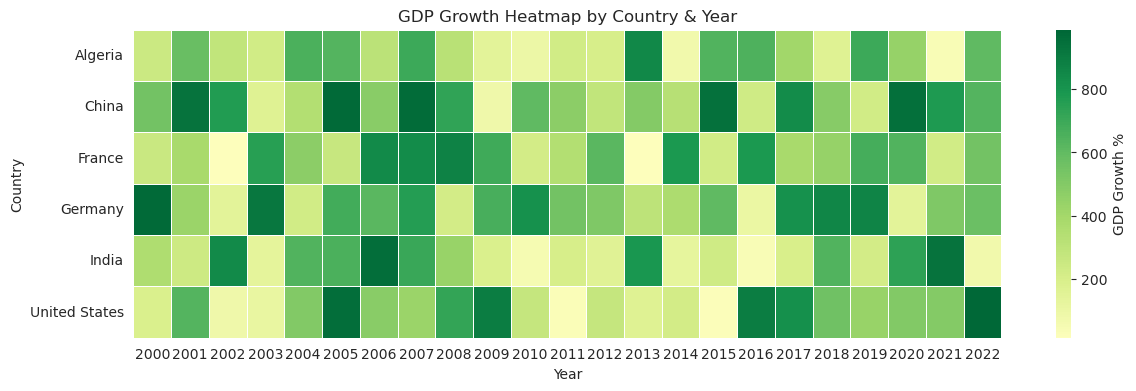

In [ ]:
if not m.empty and 'NY.GDP.MKTP.KD.ZG' in m.columns:
    targets=['Algeria','France','China','United States','Germany','Italy','Spain','Morocco','Tunisia','Turkiye','Saudi Arabia','United Arab Emirates','Brazil','India']
    matched=m[m['country'].isin(targets)]['country'].unique().tolist()
    if len(matched)<5:
        ly=m['year'].max();matched=m[m['year']==ly].nlargest(15,'NY.GDP.MKTP.CD' if 'NY.GDP.MKTP.CD' in m.columns else 'NY.GDP.MKTP.KD.ZG')['country'].tolist() if 'NY.GDP.MKTP.CD' in m.columns or 'NY.GDP.MKTP.KD.ZG' in m.columns else []
    if matched:
        h=m[m['country'].isin(matched)][['country','year','NY.GDP.MKTP.KD.ZG']].copy()
        hp=h.pivot(index='country',columns='year',values='NY.GDP.MKTP.KD.ZG')
        hp=hp.dropna(thresh=max(1,int(hp.shape[1]*0.3)),axis=1).dropna(thresh=max(1,int(hp.shape[0]*0.3)),axis=0)
        if not hp.empty:
            fig,ax=plt.subplots(figsize=(14,max(4,len(hp)*0.4)))
            sns.heatmap(hp,cmap='RdYlGn',center=0,annot=False,linewidths=.5,ax=ax,cbar_kws={'label':'GDP Growth %'})
            ax.set_title('GDP Growth Heatmap by Country & Year');ax.set_xlabel('Year');ax.set_ylabel('Country')
            save_or_show(fig,'02_gdp_growth_heatmap.png')
        else:print('Heatmap too sparse')
    else:print('No matched countries')
else:print('GDP growth data unavailable')

### Correlation Matrix

Saved /home/jovyan/imed/home/reports/figures/03_macro_correlation_matrix.png


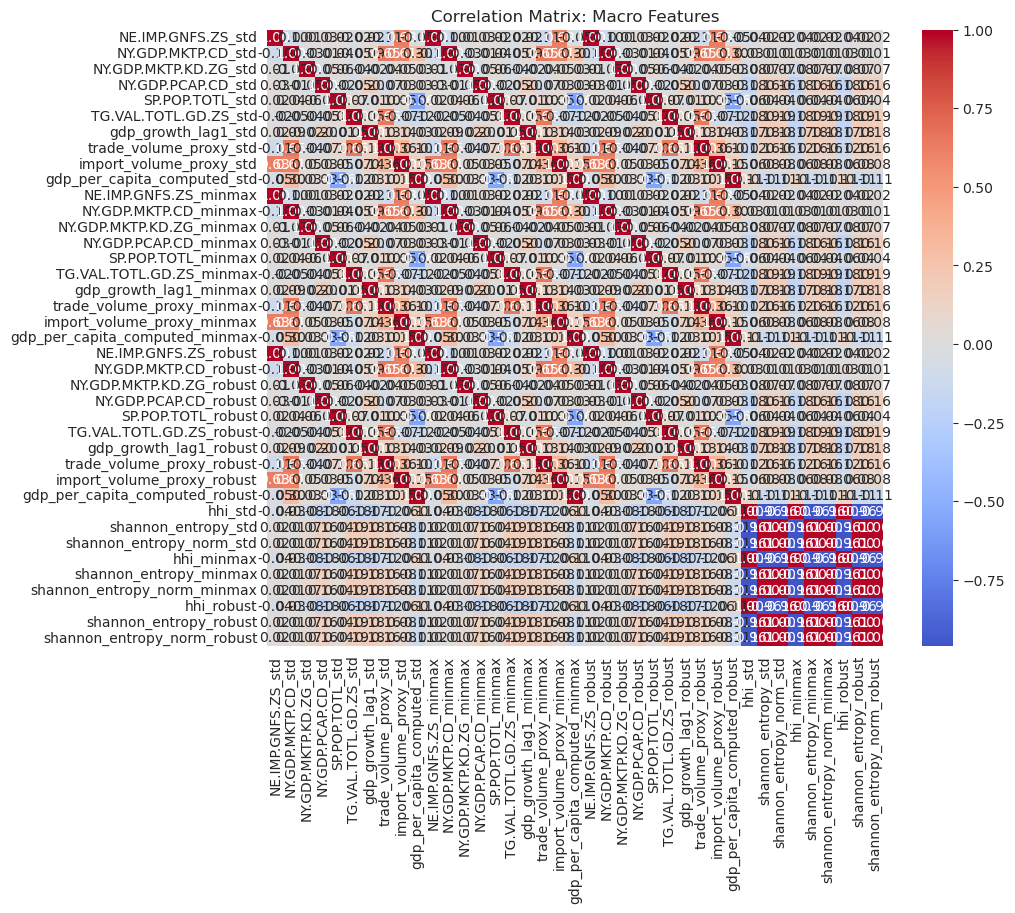

In [ ]:
if not m.empty:
    sc=[c for c in m.columns if any(c.endswith(s) for s in ('_std','_minmax','_robust'))]
    raw=['NY.GDP.MKTP.CD','NY.GDP.MKTP.KD.ZG','NY.GDP.PCAP.CD','SP.POP.TOTL','TG.VAL.TOTL.GD.ZS','NE.IMP.GNFS.ZS']
    raw=[c for c in raw if c in m.columns]
    cand=sc if len(sc)>=3 else raw
    if len(cand)>=3:
        corr_df=m[cand].dropna()
        if not corr_df.empty and len(corr_df)>5:
            corr=corr_df.corr()
            fig,ax=plt.subplots(figsize=(10,8))
            sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True,ax=ax)
            ax.set_title('Correlation Matrix: Macro Features')
            save_or_show(fig,'03_macro_correlation_matrix.png')
        else:print('Not enough observations')
    else:print('Not enough numeric columns')
else:print('Master panel unavailable')

### Diversification Over Time

Saved /home/jovyan/imed/home/reports/figures/04_diversification_trends.png


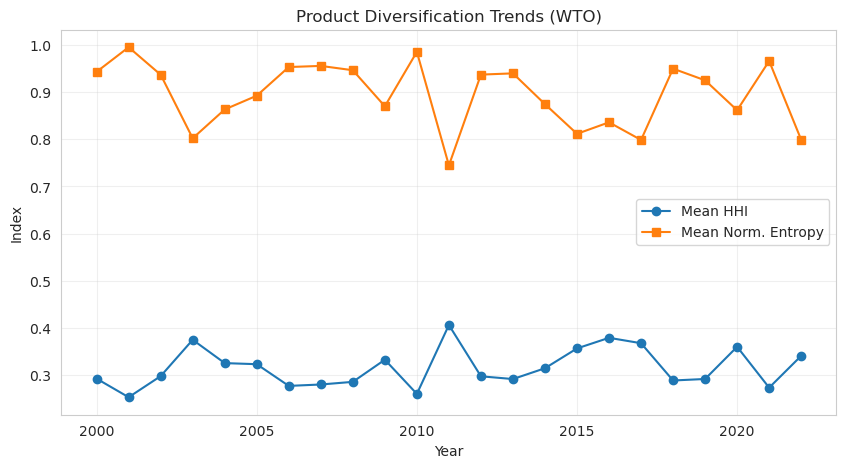

In [ ]:
if not m.empty and 'hhi' in m.columns:
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(m['year'].unique(),m.groupby('year')['hhi'].mean(),marker='o',label='Mean HHI')
    if 'shannon_entropy_norm' in m.columns:
        ax.plot(m['year'].unique(),m.groupby('year')['shannon_entropy_norm'].mean(),marker='s',label='Mean Norm. Entropy')
    ax.set_title('Product Diversification Trends (WTO)');ax.set_xlabel('Year');ax.set_ylabel('Index');ax.legend();ax.grid(True,alpha=0.3)
    save_or_show(fig,'04_diversification_trends.png')
else:print('Diversification data unavailable')

### Distribution of Scaled Features

Saved /home/jovyan/imed/home/reports/figures/05_scaled_feature_distributions.png


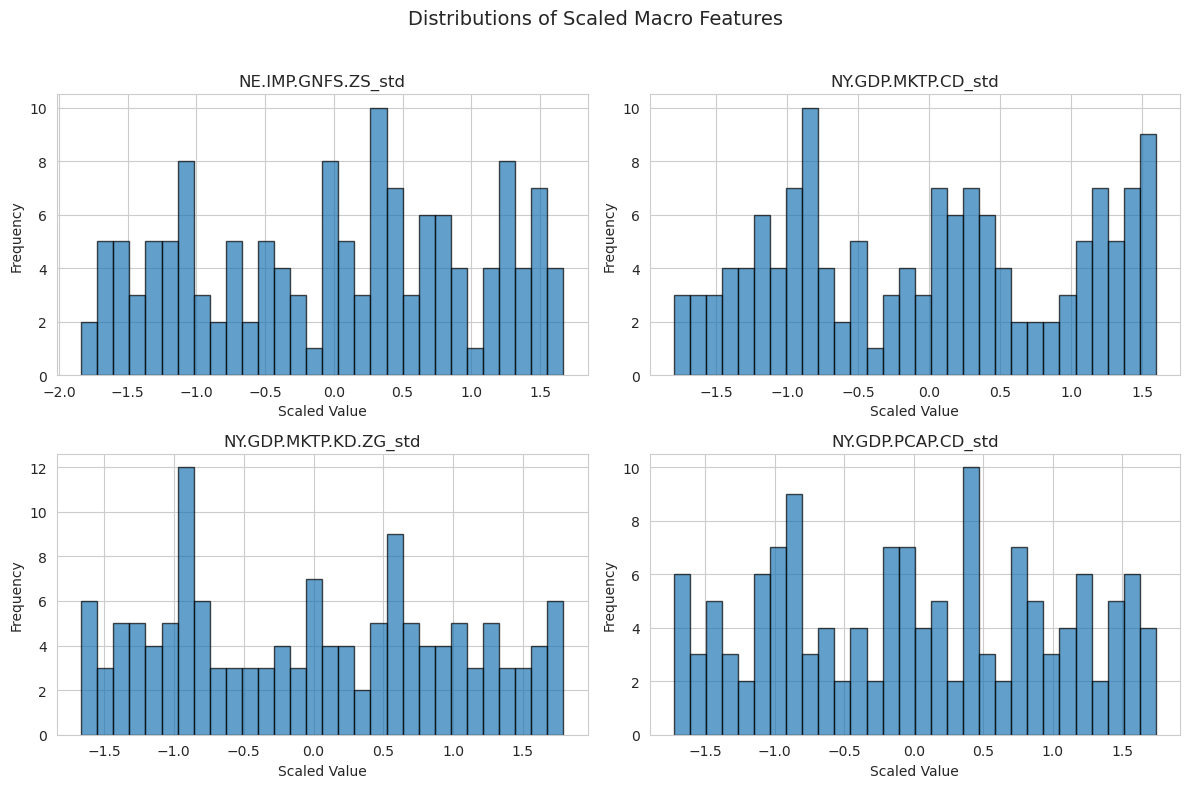

In [ ]:
if not m.empty:
    sc=[c for c in m.columns if c.endswith('_std') or c.endswith('_minmax') or c.endswith('_robust')]
    if len(sc)>=4:
        cols=sc[:4];fig,axes=plt.subplots(2,2,figsize=(12,8));axes=axes.ravel()
        for idx,col in enumerate(cols):
            data=m[col].dropna();axes[idx].hist(data,bins=30,edgecolor='k',alpha=0.7);axes[idx].set_title(col);axes[idx].set_xlabel('Scaled Value');axes[idx].set_ylabel('Frequency')
        plt.suptitle('Distributions of Scaled Macro Features',fontsize=14);plt.tight_layout(rect=[0,0,1,0.96])
        save_or_show(fig,'05_scaled_feature_distributions.png')
    else:print('Not enough scaled columns')
else:print('Master panel unavailable')

## 4.4 - Summary & Next Steps
All master datasets saved to `data/processed/`:
- `04_master_country_year.csv`
- `04_master_sector_year.csv`
Figures saved to `reports/figures/`.

##  Dataset: BACI International Trade Database
**Source:** CEPII — Centre d'Études Prospectives et d'Informations Internationales  
**Version:** HS12 V202601  
**Coverage:** 2012 – 2024 | 142,112,452 trade flows  
**Unit:** Trade values in thousands of USD  

1. Data Collection & Loading


In [ ]:
from pathlib import Path

BASE_DIR = Path.cwd()
BACI_DIR = BASE_DIR / "baci"
CONTENT_DIR = BASE_DIR / "content"

print("Base:", BASE_DIR)
print("BACI dir:", BACI_DIR)
print("Content dir:", CONTENT_DIR)

Base: /home/jovyan/imed/home/ML/imed
BACI dir: /home/jovyan/imed/home/ML/imed/baci
Content dir: /home/jovyan/imed/home/ML/imed/content


In [ ]:
import os

files = sorted([
    f for f in os.listdir(BACI_DIR)
    if f.startswith("BACI_HS12")
])

print(files)

['BACI_HS12_Y2012_V202601.csv', 'BACI_HS12_Y2013_V202601.csv', 'BACI_HS12_Y2014_V202601.csv', 'BACI_HS12_Y2015_V202601.csv', 'BACI_HS12_Y2016_V202601.csv', 'BACI_HS12_Y2017_V202601.csv', 'BACI_HS12_Y2018_V202601.csv', 'BACI_HS12_Y2019_V202601.csv', 'BACI_HS12_Y2020_V202601.csv', 'BACI_HS12_Y2021_V202601.csv', 'BACI_HS12_Y2022_V202601.csv', 'BACI_HS12_Y2023_V202601.csv', 'BACI_HS12_Y2024_V202601.csv']


In [ ]:
import pandas as pd

products = pd.read_csv(BACI_DIR / "product_codes_HS22_V202601.csv")

print(products.columns)
products.head()

Index(['code', 'description'], dtype='object')


,code,description
0,10121,"Horses: live, pure-bred breeding animals"
1,10129,"Horses: live, other than pure-bred breeding an..."
2,10130,Asses: live
3,10190,Mules and hinnies: live
4,10221,"Cattle: live, pure-bred breeding animals"


In [ ]:
countries = pd.read_csv(BACI_DIR / "country_codes_V202601.csv")

countries.head()

,country_code,country_name,country_iso2,country_iso3
0,4,Afghanistan,AF,AFG
1,8,Albania,AL,ALB
2,12,Algeria,DZ,DZA
3,16,American Samoa,AS,ASM
4,20,Andorra,AD,AND


In [ ]:
code_to_iso3 = dict(zip(countries['country_code'], countries['country_iso3']))

In [ ]:
output_file = CONTENT_DIR / "baci_clean.csv"

In [ ]:
import os

os.path.exists(output_file)

True

In [ ]:
import os

print(os.listdir(BACI_DIR))

['BACI_HS12_Y2022_V202601.csv', 'baci_clean.csv', 'product_codes_HS17_V202601.csv', 'BACI_HS12_Y2016_V202601.csv', 'BACI_HS12_Y2020_V202601.csv', 'product_codes_HS22_V202601.csv', 'baci_raw', 'baci_final.csv', 'BACI_HS12_Y2017_V202601.csv', 'BACI_HS12_Y2012_V202601.csv', 'BACI_HS12_Y2015_V202601.csv', 'BACI_HS12_Y2018_V202601.csv', 'product_codes_HS12_V202601.csv', 'BACI_HS12_Y2024_V202601.csv', 'country_codes_V202601.csv', 'BACI_HS12_Y2013_V202601.csv', 'BACI_HS12_Y2023_V202601.csv', 'BACI_HS12_Y2014_V202601.csv', 'BACI_HS12_Y2021_V202601.csv', 'BACI_HS12_Y2019_V202601.csv']


In [ ]:
import os
import pandas as pd

products = pd.read_csv(BACI_DIR / "product_codes_HS12_V202601.csv")
print("Products shape:", products.shape)
print("Columns:", products.columns.tolist())
print(products.head())

import shutil
_, _, free = shutil.disk_usage(str(BASE_DIR))
print(f"\nFree local space: {free/1e9:.1f} GB")

Products shape: (5202, 2)
Columns: ['code', 'description']
    code                                        description
0  10121           Horses: live, pure-bred breeding animals
1  10129  Horses: live, other than pure-bred breeding an...
2  10130                                        Asses: live
3  10190                            Mules and hinnies: live
4  10221           Cattle: live, pure-bred breeding animals

Free local space: 21.7 GB


2. Data Cleaning & Preprocessing


In [ ]:
import os
import pandas as pd

local_output = CONTENT_DIR / "baci_clean.csv"
fallback_output = BACI_DIR / "baci_clean.csv"

if local_output.exists():
    print(f"Using existing cleaned file: {local_output}")
elif fallback_output.exists():
    local_output = fallback_output
    print(f"Using existing cleaned file: {local_output}")
else:
    print("No cleaned file found. Heavy preprocessing is commented below.")

# ---- Heavy preprocessing (commented out because outputs already exist) ----
# import gc
# import shutil
# folder_path = BACI_DIR
# local_folder = CONTENT_DIR / "baci_raw"
# local_output = CONTENT_DIR / "baci_clean.csv"
# products = pd.read_csv(BACI_DIR / "product_codes_HS12_V202601.csv")
# files = sorted([f for f in os.listdir(folder_path) if f.startswith("BACI_HS12")])
# os.makedirs(local_folder, exist_ok=True)
# for file in files:
#     dst = os.path.join(local_folder, file)
#     if not os.path.exists(dst):
#         print(f"Copying {file}...")
#         shutil.copy(os.path.join(folder_path, file), dst)
# print("All files local ✅")
# first_write = True
# for file in files:
#     print(f"Processing {file}...")
#     chunks = pd.read_csv(
#         os.path.join(local_folder, file),
#         usecols=['t', 'i', 'j', 'k', 'v'],
#         chunksize=100000
#     )
#     for chunk in chunks:
#         chunk = chunk[chunk['v'] > 0]
#         chunk = chunk.rename(columns={
#             't':'Year','i':'Exporter','j':'Importer','k':'Product','v':'Value'
#         })
#         chunk['Exporter_ISO3'] = chunk['Exporter'].map(code_to_iso3)
#         chunk['Importer_ISO3'] = chunk['Importer'].map(code_to_iso3)
#         chunk = chunk.merge(products, left_on="Product", right_on="code", how="left")
#         chunk.to_csv(local_output, mode='w' if first_write else 'a',
#                      header=first_write, index=False)
#         first_write = False
#         del chunk
#         gc.collect()
#     print(f"  ✅ {file} done")
# final = pd.read_csv(local_output, usecols=['Year'])
# print(f"\nTotal rows: {len(final):,}")
# print(final['Year'].value_counts().sort_index())
# print("\nSaved locally ✅")

Using existing cleaned file: /home/jovyan/imed/home/ML/imed/content/baci_clean.csv


In [ ]:
import pandas as pd

df = pd.read_csv(CONTENT_DIR / "baci_clean.csv", nrows=500000)

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== NULL COUNT ===")
print(df.isnull().sum())

print("\n=== NULL PERCENTAGE ===")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n=== SAMPLE ===")
print(df.head())

=== SHAPE ===
(500000, 9)

=== COLUMNS ===
['Year', 'Exporter', 'Importer', 'Product', 'Value', 'Exporter_ISO3', 'Importer_ISO3', 'code', 'description']

=== NULL COUNT ===
Year             0
Exporter         0
Importer         0
Product          0
Value            0
Exporter_ISO3    0
Importer_ISO3    0
code             0
description      0
dtype: int64

=== NULL PERCENTAGE ===
Year            0.00
Exporter        0.00
Importer        0.00
Product         0.00
Value           0.00
Exporter_ISO3   0.00
Importer_ISO3   0.00
code            0.00
description     0.00
dtype: float64

=== SAMPLE ===
   Year  Exporter  Importer  Product  Value Exporter_ISO3 Importer_ISO3  \
0  2012         4         8   610469   2.73           AFG           ALB   
1  2012         4         8   630900   0.12           AFG           ALB   
2  2012         4        12    91099   1.19           AFG           DZA   
3  2012         4        32   392630   1.29           AFG           ARG   
4  2012         4      

In [ ]:
import numpy as np

print("=== VALUE DISTRIBUTION ===")
print(df['Value'].describe())

print("\n=== PERCENTILES ===")
percentiles = [90, 95, 99, 99.9, 99.99]
for p in percentiles:
    print(f"  {p}th percentile: {np.percentile(df['Value'], p):,.2f}")

print("\n=== SKEWNESS ===")
print(f"  Skewness: {df['Value'].skew():.2f}")

print("\n=== TOP 10 VALUES ===")
print(df['Value'].nlargest(10).values)

=== VALUE DISTRIBUTION ===
count      500,000.00
mean         1,659.57
std         95,190.85
min              0.00
25%              1.13
50%              9.89
75%             85.19
max     42,695,465.25
Name: Value, dtype: float64

=== PERCENTILES ===
  90th percentile: 600.03
  95th percentile: 1,893.01
  99th percentile: 15,799.25
  99.9th percentile: 182,572.33
  99.99th percentile: 1,501,201.22

=== SKEWNESS ===
  Skewness: 302.68

=== TOP 10 VALUES ===
[42695465.252 33373390.248 17700552.551 13301066.236 13093875.086
 10657878.786  9450711.645  9286150.188  7778168.203  6302323.995]


In [ ]:
import os

baci_final = BACI_DIR / "baci_final.csv"
print("Using:", baci_final)
if baci_final.exists():
    print(f"Size: {baci_final.stat().st_size/1e9:.1f} GB")
else:
    print("baci_final.csv not found in BACI dir")

Using: /home/jovyan/imed/home/ML/imed/baci/baci_final.csv
Size: 22.5 GB


In [ ]:
import pandas as pd

df = pd.read_csv(BACI_DIR / "baci_final.csv", nrows=500000)

print("COLUMNS")
print(df.columns.tolist())

print("\n SHAPE SAMPLE")
print(df.shape)

print("\nNULLS")
print(df.isnull().sum())

print("\nSAMPLE")
print(df.head())

print("\n VALUE STATS")
print(df['Value'].describe())

print("\n OUTLIER COUNT")
print(df['Is_Outlier'].value_counts())

COLUMNS
['Year', 'Exporter', 'Importer', 'Product', 'Value', 'Exporter_ISO3', 'Importer_ISO3', 'description', 'Log_Value', 'Is_Outlier']

 SHAPE SAMPLE
(500000, 10)

NULLS
Year             0
Exporter         0
Importer         0
Product          0
Value            0
Exporter_ISO3    0
Importer_ISO3    0
description      0
Log_Value        0
Is_Outlier       0
dtype: int64

SAMPLE
   Year  Exporter  Importer  Product  Value Exporter_ISO3 Importer_ISO3  \
0  2012         4         8   610469   2.73           AFG           ALB   
1  2012         4         8   630900   0.12           AFG           ALB   
2  2012         4        12    91099   1.19           AFG           DZA   
3  2012         4        32   392630   1.29           AFG           ARG   
4  2012         4        32   710310   0.10           AFG           ARG   

                                         description  Log_Value  Is_Outlier  
0  Trousers, bib and brace overalls, breeches and...       1.32           0  
1         

In [ ]:
dupes = df.duplicated(subset=['Year','Exporter_ISO3','Importer_ISO3','Product']).sum()
print(f"Duplicate rows: {dupes}")
print(f"Total rows in sample: {len(df)}")
print(f"\nSample:\n{df.head()}")

Duplicate rows: 0
Total rows in sample: 500000

Sample:
   Year  Exporter  Importer  Product  Value Exporter_ISO3 Importer_ISO3  \
0  2012         4         8   610469   2.73           AFG           ALB   
1  2012         4         8   630900   0.12           AFG           ALB   
2  2012         4        12    91099   1.19           AFG           DZA   
3  2012         4        32   392630   1.29           AFG           ARG   
4  2012         4        32   710310   0.10           AFG           ARG   

                                         description  Log_Value  Is_Outlier  
0  Trousers, bib and brace overalls, breeches and...       1.32           0  
1            Clothing: worn, and other worn articles       0.11           0  
2                 Spices: n.e.c. in heading no. 0910       0.78           0  
3  Plastics: fittings for furniture, coachwork or...       0.83           0  
4  Stones: precious (other than diamonds) and sem...       0.09           0  


In [ ]:
import pandas as pd

global_demand = pd.read_csv(CONTENT_DIR / "global_demand.csv")
total_exports = pd.read_csv(CONTENT_DIR / "total_exports.csv")
product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")

print(f"Global Demand shape: {global_demand.shape}")
print(f"Total Exports shape: {total_exports.shape}")
print(f"Product Export shape: {product_export.shape}")

# ---- Heavy aggregation (commented out because outputs already exist) ----
# import numpy as np
# import gc
# from collections import defaultdict
# file_path = CONTENT_DIR / "baci_final.csv"
# global_demand_acc = defaultdict(float)
# total_exports_acc = defaultdict(float)
# product_export_acc = defaultdict(float)
# print("computing aggregate")
# for i, chunk in enumerate(pd.read_csv(file_path,
#                            usecols=['Year','Exporter_ISO3','Importer_ISO3','Product','Value'],
#                            chunksize=100000)):
#     for _, row in chunk.iterrows():
#         y, exp, imp, p, v = row['Year'], row['Exporter_ISO3'], row['Importer_ISO3'], row['Product'], row['Value']
#         global_demand_acc[(y, p)] += v
#         total_exports_acc[(y, exp)] += v
#         product_export_acc[(y, exp, p)] += v
#     if i % 100 == 0:
#         print(f"  Processed {i*100000:,} rows...")
#     gc.collect()
# print("Converting to DataFrames...")
# global_demand = pd.DataFrame(
#     [(y, p, v) for (y,p), v in global_demand_acc.items()],
#     columns=['Year','Product','Global_Demand']
# )
# total_exports = pd.DataFrame(
#     [(y, e, v) for (y,e), v in total_exports_acc.items()],
#     columns=['Year','Exporter_ISO3','Total_Exports']
# )
# product_export = pd.DataFrame(
#     [(y, e, p, v) for (y,e,p), v in product_export_acc.items()],
#     columns=['Year','Exporter_ISO3','Product','Product_Export_Total']
# )
# global_demand.to_csv(CONTENT_DIR / "global_demand.csv", index=False)
# total_exports.to_csv(CONTENT_DIR / "total_exports.csv", index=False)
# product_export.to_csv(CONTENT_DIR / "product_export.csv", index=False)
# print("done")
# del global_demand_acc, total_exports_acc, product_export_acc
# gc.collect()

Global Demand shape: (67585, 3)
Total Exports shape: (2939, 3)
Product Export shape: (7217808, 7)


In [ ]:
# Market Share + Growth Rate

product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")
global_demand = pd.read_csv(CONTENT_DIR / "global_demand.csv")

print(product_export.columns)
print("starting")

# Remove old calculated columns if they already exist
product_export = product_export.drop(
    columns=[
        "Global_Demand",
        "Market_Share",
        "Export_Growth_Rate",
        "Global_Demand_x",
        "Global_Demand_y"
    ],
    errors="ignore"
)

# Keep only the needed columns from global_demand
global_demand = global_demand[["Year", "Product", "Global_Demand"]]

# Merge cleanly
product_export = product_export.merge(
    global_demand,
    on=["Year", "Product"],
    how="left"
)

# Calculate market share
product_export["Market_Share"] = (
    product_export["Product_Export_Total"] / product_export["Global_Demand"] * 100
).round(4)

# Calculate growth rate
product_export = product_export.sort_values(
    ["Exporter_ISO3", "Product", "Year"]
)

product_export["Export_Growth_Rate"] = (
    product_export.groupby(["Exporter_ISO3", "Product"])["Product_Export_Total"]
    .pct_change() * 100
).round(4)

# Save result
product_export.to_csv(CONTENT_DIR / "product_export.csv", index=False)

print("done")
print(product_export.shape)
print(product_export.head())

Index(['Year', 'Exporter_ISO3', 'Product', 'Product_Export_Total',
       'Global_Demand', 'Market_Share', 'Export_Growth_Rate'],
      dtype='object')
starting


done
(7217808, 7)
   Year Exporter_ISO3  Product  Product_Export_Total  Global_Demand  \
0  2014           ABW    10121                  5.00   1,295,225.08   
1  2017           ABW    10121                 74.20   1,458,973.48   
2  2018           ABW    10121                  8.62   1,451,991.23   
3  2019           ABW    10121                137.27   1,499,756.43   
4  2020           ABW    10121                 12.79   1,451,853.91   

   Market_Share  Export_Growth_Rate  
0          0.00                 NaN  
1          0.01            1,383.92  
2          0.00              -88.39  
3          0.01            1,493.35  
4          0.00              -90.68  


In [ ]:
total_exports = pd.read_csv(CONTENT_DIR / "total_exports.csv")
product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")

print("start")
hhi_df = product_export.merge(total_exports, on=['Year','Exporter_ISO3'], how='left')
hhi_df['weight'] = (hhi_df['Product_Export_Total'] / hhi_df['Total_Exports']) ** 2
hhi = hhi_df.groupby(['Year','Exporter_ISO3'])['weight'].sum().reset_index()
hhi.columns = ['Year','Exporter_ISO3','HHI']
hhi['HHI'] = hhi['HHI'].round(6)

hhi.to_csv(CONTENT_DIR / "hhi.csv", index=False)
print("done ")
print(hhi.shape)
print(hhi.head())

start
done 
(2939, 3)
   Year Exporter_ISO3  HHI
0  2012           ABW 0.61
1  2012           AFG 0.14
2  2012           AGO 0.89
3  2012           AIA 0.13
4  2012           ALB 0.05


In [ ]:
product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")
global_demand = pd.read_csv(CONTENT_DIR / "global_demand.csv")

algeria = product_export[product_export['Exporter_ISO3'] == 'DZA'][
    ['Year','Product','Product_Export_Total','Market_Share']
].copy()
algeria.columns = ['Year','Product','Algeria_Exports','Algeria_Market_Share']

# Merge with global demand so we can see the diffs
algeria = algeria.merge(global_demand, on=['Year','Product'], how='right')
algeria['Algeria_Exports'] = algeria['Algeria_Exports'].fillna(0)
algeria['Algeria_Market_Share'] = algeria['Algeria_Market_Share'].fillna(0)
algeria['Untapped_Potential'] = algeria['Global_Demand'] - algeria['Algeria_Exports']

algeria.to_csv(CONTENT_DIR / "algeria_features.csv", index=False)
print("done")
print(algeria.shape)
print(algeria.head())

done
(67585, 6)
   Year  Product  Algeria_Exports  Algeria_Market_Share  Global_Demand  \
0  2012   610469             0.00                  0.00     822,330.02   
1  2012   630900             5.02                  0.00   3,886,645.95   
2  2012    91099             9.17                  0.00     583,110.27   
3  2012   392630            24.72                  0.00   3,252,724.74   
4  2012   710310             0.00                  0.00     680,218.86   

   Untapped_Potential  
0          822,330.02  
1        3,886,640.93  
2          583,101.11  
3        3,252,700.02  
4          680,218.86  


In [ ]:
import pandas as pd

baci_features = pd.read_csv(CONTENT_DIR / "baci_features.csv")
print("Loaded baci_features.csv", baci_features.shape)
baci_features.head()

# ---- Heavy join (commented out because outputs already exist) ----
# import gc
# import shutil
# product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")
# total_exports = pd.read_csv(CONTENT_DIR / "total_exports.csv")
# hhi = pd.read_csv(CONTENT_DIR / "hhi.csv")
# algeria = pd.read_csv(CONTENT_DIR / "algeria_features.csv")
# local_output = CONTENT_DIR / "baci_features.csv"
# first_write = True
# for chunk in pd.read_csv(BACI_DIR / "baci_final.csv", chunksize=100000):
#     chunk = chunk.merge(product_export[['Year','Exporter_ISO3','Product',
#                                          'Product_Export_Total','Market_Share',
#                                          'Export_Growth_Rate','Global_Demand']],
#                         on=['Year','Exporter_ISO3','Product'], how='left')
#     chunk = chunk.merge(total_exports, on=['Year','Exporter_ISO3'], how='left')
#     chunk = chunk.merge(hhi, on=['Year','Exporter_ISO3'], how='left')
#     chunk = chunk.merge(algeria[['Year','Product','Algeria_Exports',
#                                   'Algeria_Market_Share','Untapped_Potential']],
#                         on=['Year','Product'], how='left')
#     chunk.to_csv(local_output, mode='w' if first_write else 'a',
#                  header=first_write, index=False)
#     first_write = False
#     del chunk
#     gc.collect()
# print("done")

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 🔍 Insight — Global Trade Demand Trends

- A sharp drop is visible around **2020**, directly caused by the COVID-19 pandemic
  disrupting global logistics, demand, and production.
- Trade rebounded strongly in **2021–2022**, with a partial correction in 2023.
- This context is important: Algeria's export strategy must account for post-COVID
  global demand recovery and the shifting of supply chains away from single-source dependency.

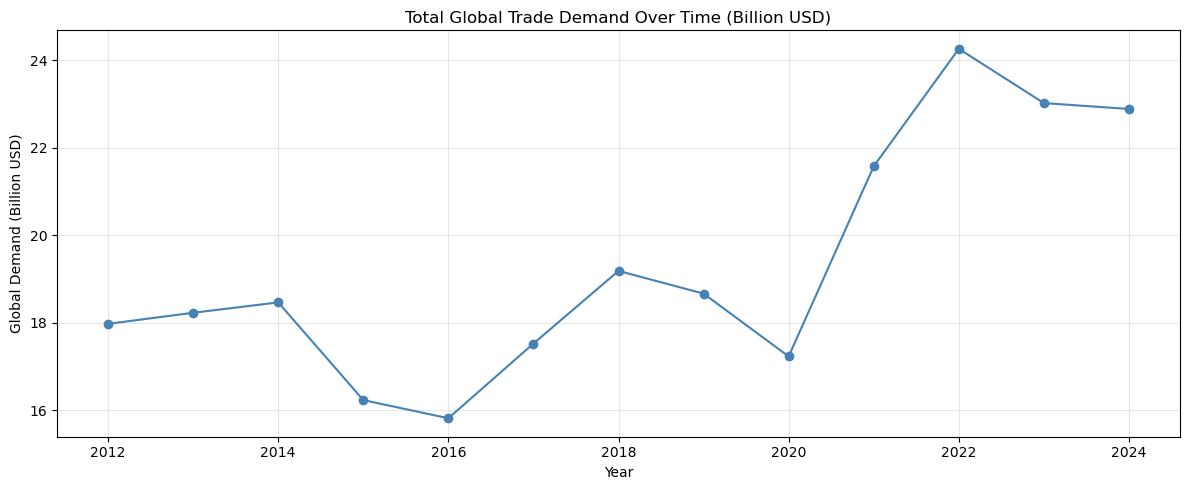

In [12]:
from pathlib import Path

# ── EDA 2: Global Demand Over Time ──────────────────────────────────────────
CONTENT_DIR = Path(r"C:\Users\ADMIN\Desktop\mlprojfinal\\")
global_demand = pd.read_csv(CONTENT_DIR / "global_demand.csv")

gd_year = global_demand.groupby('Year')['Global_Demand'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(gd_year['Year'], gd_year['Global_Demand'] / 1e9, marker='o', color='steelblue')
plt.title('Total Global Trade Demand Over Time (Billion USD)')
plt.xlabel('Year')
plt.ylabel('Global Demand (Billion USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Insight — Highest Demand Products Globally

- The top globally demanded products are dominated by **energy commodities, machinery,
  vehicles, and chemicals** — reflecting the structure of industrial economies.
- Several high-demand agricultural products (cereals, oils, vegetables) and
  manufactured goods appear, which are sectors where Algeria has productive capacity.
- This chart acts as a **target map**: products with massive global demand and low
  Algerian market share represent the highest-priority opportunities to investigate.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16928\3402869946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Global_Demand', y=top_products['Product'].astype(str),


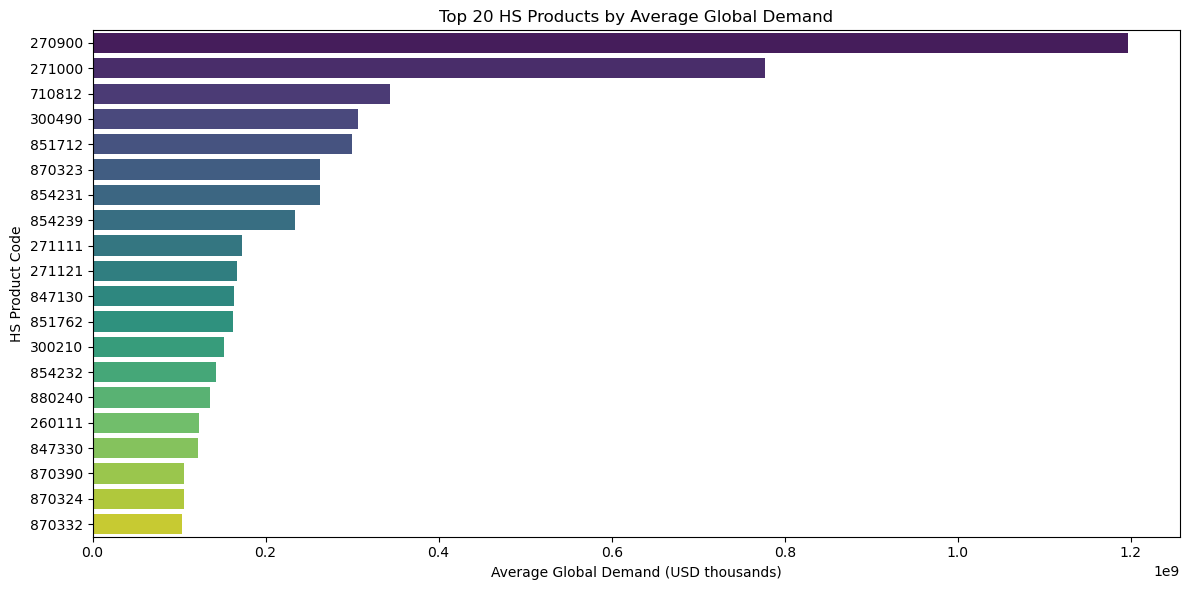

In [15]:
# ── EDA 3: Top 20 Products by Average Global Demand ─────────────────────────
top_products = (global_demand.groupby('Product')['Global_Demand']
                .mean()
                .sort_values(ascending=False)
                .head(20)
                .reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='Global_Demand', y=top_products['Product'].astype(str),
            palette='viridis')
plt.title('Top 20 HS Products by Average Global Demand')
plt.xlabel('Average Global Demand (USD thousands)')
plt.ylabel('HS Product Code')
plt.tight_layout()
plt.show()

## 🔍 Insight — Algeria's Export Trajectory

- Algeria's total exports in the BACI data show significant volatility across years,
  reflecting the dominance of hydrocarbon revenues in the overall export basket.
- Non-hydrocarbon product exports remain relatively flat and low compared to the
  country's economic size, confirming the diversification challenge described in the
  project brief.
- Any growth visible in recent years (2021–2023) likely reflects oil price recovery
  rather than structural diversification — the product-level breakdown in subsequent
  analyses will clarify this.

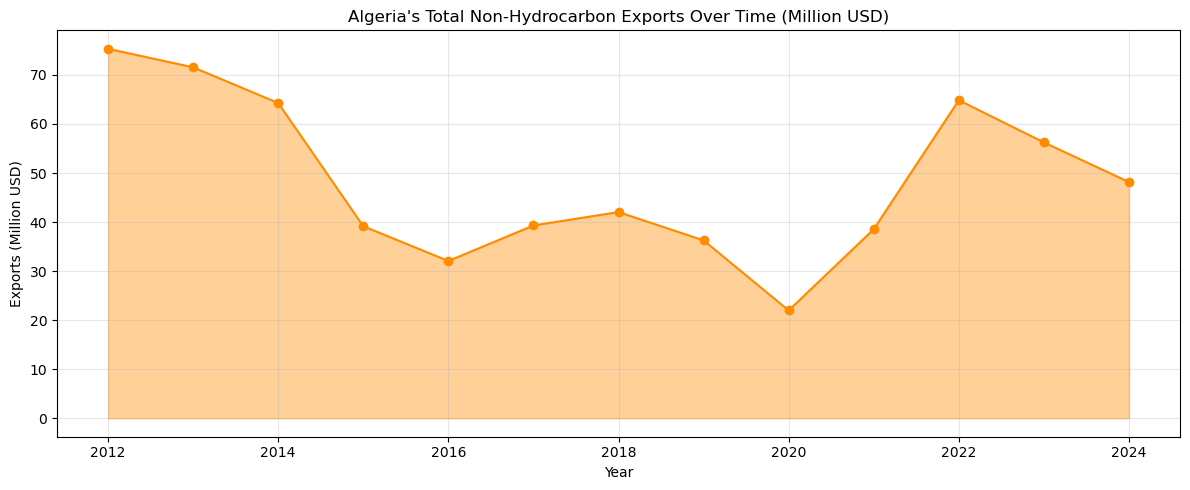

In [16]:
# ── EDA 4: Algeria Export Trends Over Time ──────────────────────────────────
algeria = pd.read_csv(CONTENT_DIR / "algeria_features.csv")

alg_year = algeria.groupby('Year')['Algeria_Exports'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.fill_between(alg_year['Year'], alg_year['Algeria_Exports'] / 1e6,
                 alpha=0.4, color='darkorange')
plt.plot(alg_year['Year'], alg_year['Algeria_Exports'] / 1e6,
         color='darkorange', marker='o')
plt.title("Algeria's Total Non-Hydrocarbon Exports Over Time (Million USD)")
plt.xlabel('Year')
plt.ylabel('Exports (Million USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Insight — Algeria's Market Share Distribution (2024)

- Out of all products traded globally, Algeria has **0% market share in 3,905 products** — 
  meaning it exports absolutely nothing in the vast majority of product categories 
  where global demand exists. This is the most striking finding of this analysis.

- Only **27 products** have a market share above 1%, and just **11 above 5%** — 
  these are almost entirely dominated by crude oil, refined petroleum, and a 
  handful of raw materials like natural gas and fertilizers.

- Only **3 products** exceed 10% market share — confirming that Algeria's global 
  competitiveness is concentrated in an extremely narrow set of commodities.

- The right plot (zoomed ≤5%) shows that even among the products Algeria does export, 
  the vast majority have a share barely above 0% — meaning Algeria is present but 
  not competitive in most of them.

- This distribution directly justifies the need for this ML project: with 3,905 
  untouched product categories, the classification model's job is to identify 
  which of these represent realistic entry points for Algerian exporters.

- **For CACI:** the 27 products above 1% are Algeria's current strengths to protect 
  and scale — the 3,905 at 0% are the opportunity universe to prioritize and invest in.

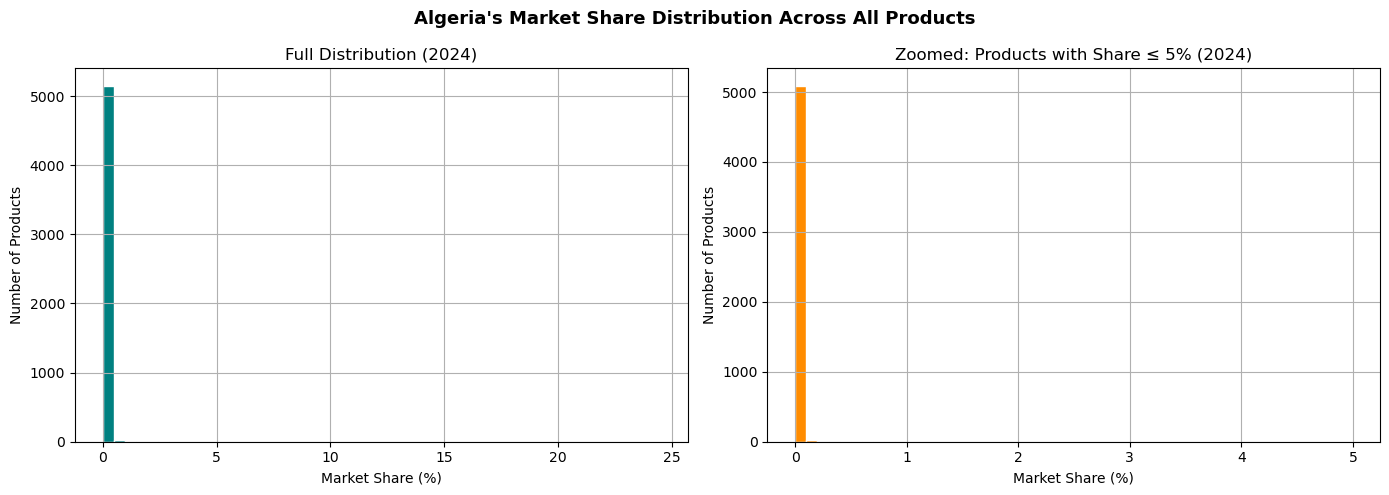

Products with 0% share:   3905
Products with >1% share:  27
Products with >5% share:  11
Products with >10% share: 3


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

CONTENT_DIR = r"C:\Users\ADMIN\Desktop\mlprojfinal\\"

algeria = pd.read_csv(CONTENT_DIR + "algeria_features.csv")
latest_year = algeria['Year'].max()
alg_latest = algeria[algeria['Year'] == latest_year].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: full range (shows oil/gas outliers)
alg_latest['Algeria_Market_Share'].hist(bins=50, color='teal',
                                        edgecolor='white', ax=axes[0])
axes[0].set_title(f"Full Distribution ({latest_year})")
axes[0].set_xlabel("Market Share (%)")
axes[0].set_ylabel("Number of Products")

# Right plot: zoomed to ≤5% (shows non-hydrocarbon reality)
alg_latest[alg_latest['Algeria_Market_Share'] <= 5]['Algeria_Market_Share'].hist(
    bins=50, color='darkorange', edgecolor='white', ax=axes[1])
axes[1].set_title(f"Zoomed: Products with Share ≤ 5% ({latest_year})")
axes[1].set_xlabel("Market Share (%)")
axes[1].set_ylabel("Number of Products")

plt.suptitle("Algeria's Market Share Distribution Across All Products",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Products with 0% share:  ", (alg_latest['Algeria_Market_Share'] == 0).sum())
print("Products with >1% share: ", (alg_latest['Algeria_Market_Share'] > 1).sum())
print("Products with >5% share: ", (alg_latest['Algeria_Market_Share'] > 5).sum())
print("Products with >10% share:", (alg_latest['Algeria_Market_Share'] > 10).sum())

## 🔍 Insight — Top Untapped Export Opportunities for Algeria (2024)

- `Untapped_Potential = Global_Demand - Algeria_Exports` measures how much of the 
  world's demand Algeria is currently not serving — the larger the bar, the bigger 
  the missed opportunity.

- **Crude petroleum (270900)** dominates with over **1.3 billion USD** in untapped 
  potential, followed by **refined petroleum products (271000)** at ~850M USD — 
  this suggests Algeria could capture significantly more value by scaling refining 
  capacity and exporting finished fuel products rather than raw crude alone.

- **Gold (710812)** ranks 3rd — Algeria holds natural reserves but lacks the 
  processing and export infrastructure to monetize them at scale.

- A strong cluster of **electronics (854231, 854239, 851712)** and **pharmaceuticals 
  (300490, 300210)** appears in the top 10 — pharmaceuticals are a realistic 
  medium-term target given Algeria's growing domestic industry, while electronics 
  represent longer-term industrial development goals.

- **Passenger vehicles (870390, 870323)** also appear, aligning with Algeria's 
  recent automotive assembly investments and suggesting export potential if 
  production scales up.

- **For the ML classification model:** these untapped potential values serve as 
  a direct input feature to label country-product pairs as high/medium/low 
  opportunity — the higher the gap, the stronger the signal for "high opportunity."

- **Actionable insight for CACI:** Short-term priorities should focus on refined 
  petroleum, pharmaceuticals, and gold processing — sectors where Algeria already 
  has raw material access and an emerging industrial base.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16928\2269294941.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=alg_top, x='Untapped_Potential',


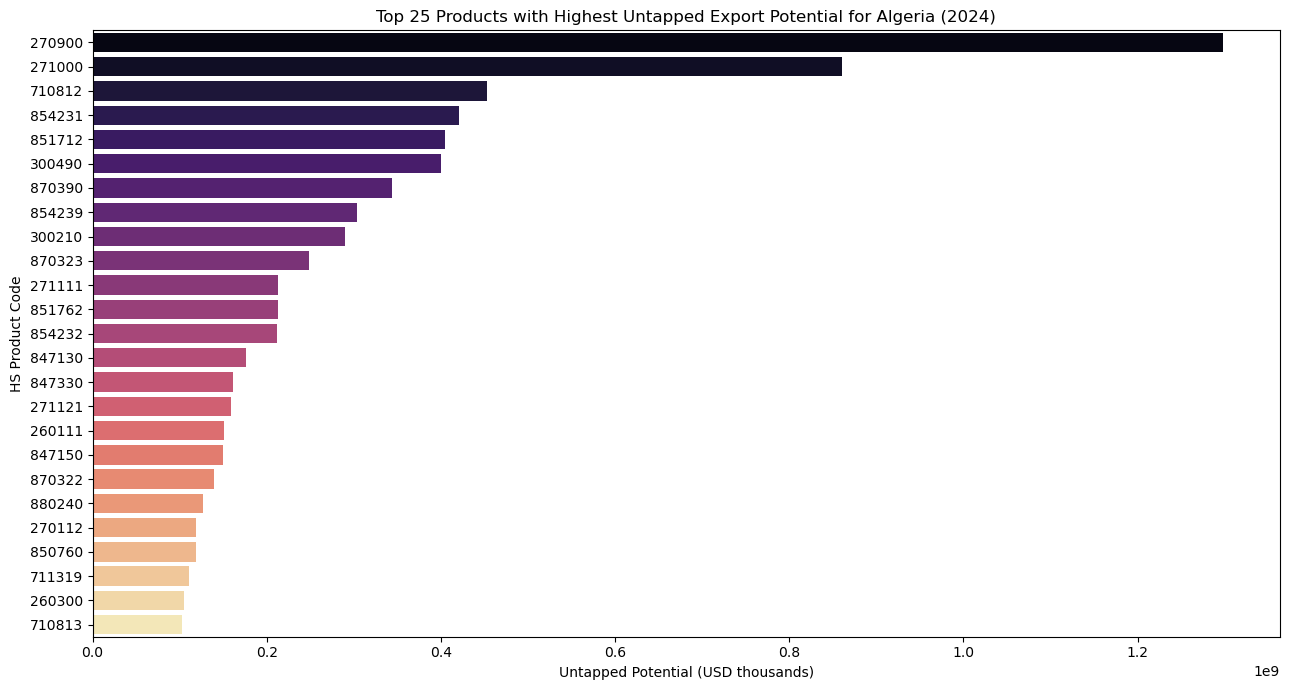

In [18]:
# ── EDA 6: Top Products by Untapped Potential (Latest Year) ─────────────────
alg_top = (alg_latest.sort_values('Untapped_Potential', ascending=False)
           .head(25)
           .copy())

plt.figure(figsize=(13, 7))
sns.barplot(data=alg_top, x='Untapped_Potential',
            y=alg_top['Product'].astype(str), palette='magma')
plt.title(f"Top 25 Products with Highest Untapped Export Potential for Algeria ({latest_year})")
plt.xlabel("Untapped Potential (USD thousands)")
plt.ylabel("HS Product Code")
plt.tight_layout()
plt.show()

## 🔍 Insight — Export Concentration vs World Average

- Algeria's HHI is **significantly higher** than the world average across all years,
  confirming that its export basket is far more concentrated than a typical country.
- A high HHI (close to 1) means exports are dominated by very few products — in
  Algeria's case, almost entirely hydrocarbons.
- The world average HHI has remained relatively stable, meaning most countries maintain
  diversified export portfolios — Algeria is an outlier.
- Whether Algeria's HHI is decreasing over time is a critical indicator of whether
  diversification policy is actually working. A flat or rising HHI signals the urgency
  of the problem this project addresses.

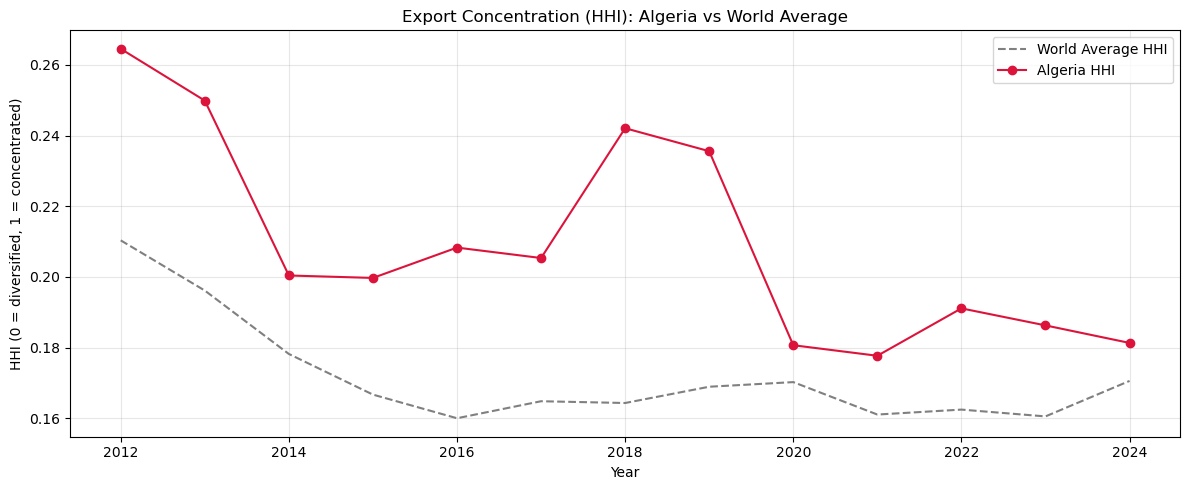

In [19]:
# ── EDA 7: Algeria's HHI Concentration Trend vs World Average ───────────────
hhi = pd.read_csv(CONTENT_DIR / "hhi.csv")

alg_hhi = hhi[hhi['Exporter_ISO3'] == 'DZA'].sort_values('Year')
world_avg_hhi = hhi.groupby('Year')['HHI'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(world_avg_hhi['Year'], world_avg_hhi['HHI'],
         label='World Average HHI', color='gray', linestyle='--')
plt.plot(alg_hhi['Year'], alg_hhi['HHI'],
         label="Algeria HHI", color='crimson', marker='o')
plt.title("Export Concentration (HHI): Algeria vs World Average")
plt.xlabel("Year")
plt.ylabel("HHI (0 = diversified, 1 = concentrated)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Insight — Volatility of Algeria's Export Growth

- The distribution of Algeria's export growth rates is extremely wide and roughly
  centered near zero, with many products showing both large positive and large negative swings.
- High volatility means Algeria's non-hydrocarbon exports are unstable — products enter
  and exit markets irregularly rather than growing steadily.
- Products with consistently positive growth rates (right tail of the distribution)
  are Algeria's strongest performers and the most viable candidates for scaling up.
- This volatility pattern also justifies the use of forecasting models: simple trend
  extrapolation would be unreliable, and ML-based forecasting can better capture the
  irregular patterns.

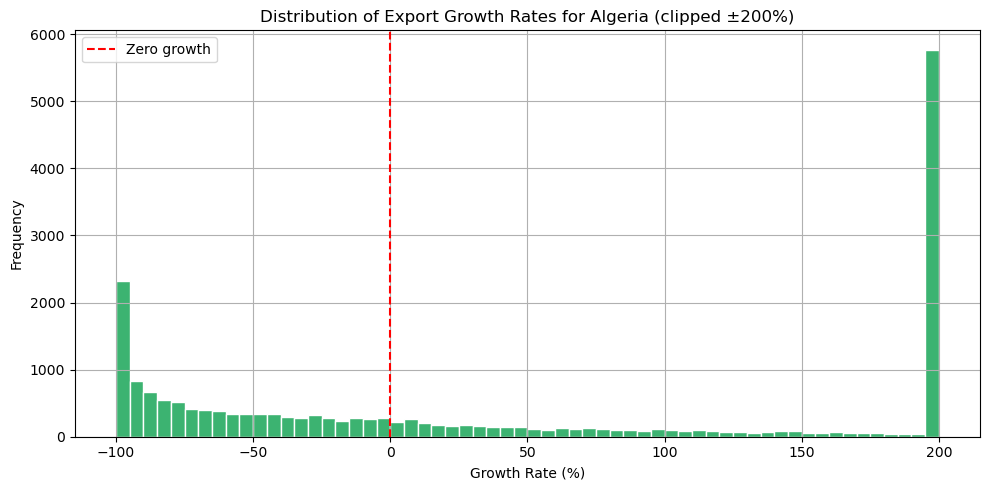

In [22]:
# ── EDA 8: Export Growth Rate Distribution for Algeria ──────────────────────
product_export = pd.read_csv(CONTENT_DIR / "product_export.csv")
alg_pe = product_export[product_export['Exporter_ISO3'] == 'DZA'].dropna(
    subset=['Export_Growth_Rate'])

plt.figure(figsize=(10, 5))
alg_pe['Export_Growth_Rate'].clip(-200, 200).hist(bins=60, color='mediumseagreen',
                                                    edgecolor='white')
plt.title("Distribution of Export Growth Rates for Algeria (clipped ±200%)")
plt.xlabel("Growth Rate (%)")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--', label='Zero growth')
plt.legend()
plt.tight_layout()
plt.show()

## 🔍 Insight — Algeria's Consistent vs Emerging Export Strengths

- The heatmap reveals which products Algeria has **maintained a presence in over the years**
  (consistently warm rows) versus products where share has recently appeared or grown.
- Products with consistently high market share across all years represent Algeria's
  **established export base** — these are the sectors to protect and build on.
- Products showing growing market share in recent years (2020–2024) signal **emerging
  competitiveness** — these are prime candidates for the "high opportunity" classification label.
- Gaps or sudden drops in share for a product may indicate market access issues,
  quality barriers, or competition that the policy layer should investigate.

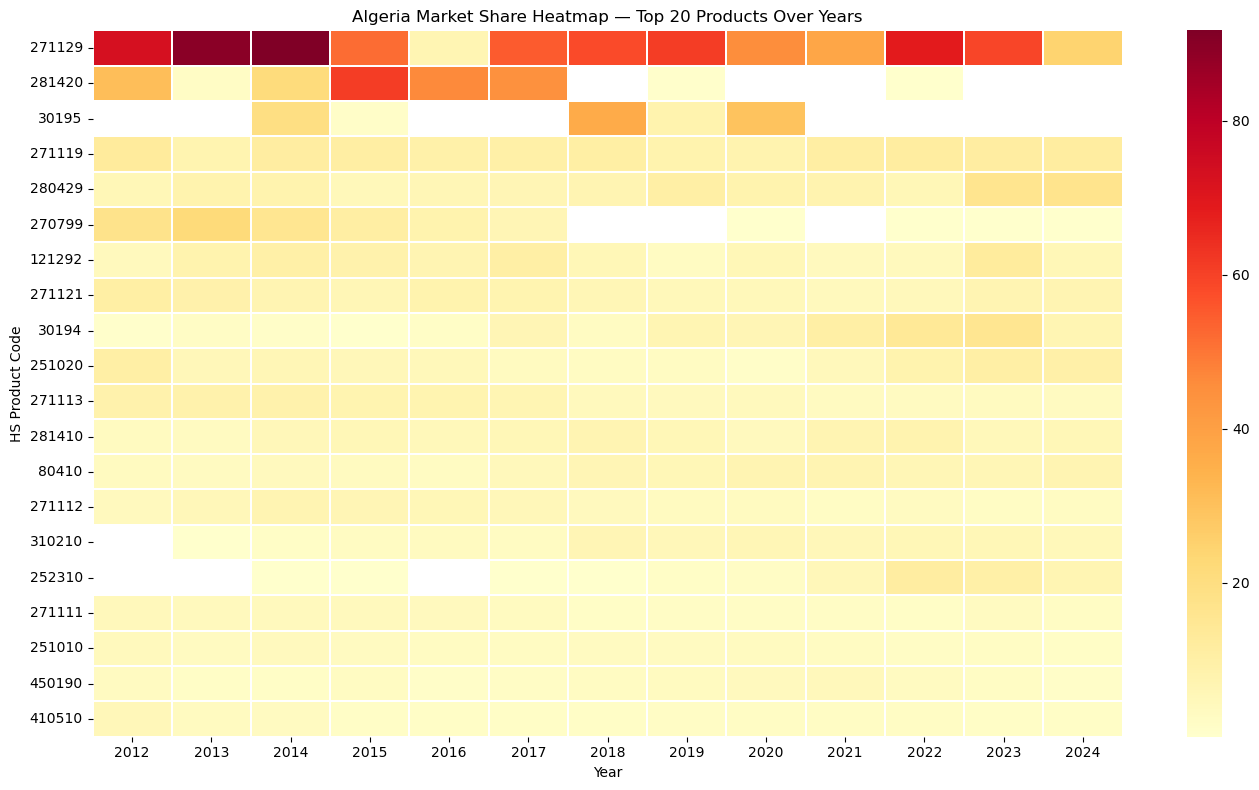

In [21]:
# ── EDA 9: Algeria Market Share Heatmap – Top Products × Years ──────────────
pivot = (algeria[algeria['Algeria_Market_Share'] > 0]
         .pivot_table(index='Product', columns='Year',
                      values='Algeria_Market_Share', aggfunc='mean')
         .dropna(thresh=5))

# Keep only top 20 products by average share
top20 = pivot.mean(axis=1).sort_values(ascending=False).head(20).index
pivot_top = pivot.loc[top20]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_top, cmap='YlOrRd', linewidths=0.3, fmt='.2f', annot=False)
plt.title("Algeria Market Share Heatmap — Top 20 Products Over Years")
plt.xlabel("Year")
plt.ylabel("HS Product Code")
plt.tight_layout()
plt.show()